# Spaceship Titanic: Classification and Interpretability

Binary classification on the Kaggle *Spaceship Titanic* dataset. Hierarchical imputation, six engineered feature groups, five models compared with 5-fold CV and GridSearch tuning, XGBoost selected by AUC-ROC, and SHAP-based interpretability.

*The notebook text is in Portuguese. An English summary of the approach and results is in the README of this folder.*

---

# Spaceship Titanic

> **Objetivo:** Prever quais passageiros foram transportados para outra dimensão após a colisão da nave Titanic com uma anomalia espaço-temporal

| Etapa | Descrição |
|-------|-----------|
| 1 | Setup & Junção Train + Test |
| 2 | Análise Inicial & Qualidade dos Dados |
| 3 | EDA Análise Exploratória de Dados |
| 4 | Feature Engineering |
| 5 | Pré-processamento & Preparação para Modelagem |
| 6 | Modelagem & Avaliação |
| 7 | Interpretabilidade (SHAP, PDP, LIME) |
| 8 | Submissão Final |


---
## Seção 1 Setup & Junção Train + Test



In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
 confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
 'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
np.random.seed(SEED)
print(" Imports concluídos!")


 Imports concluídos!


In [ ]:
# Carregamento dos dados
train_raw = pd.read_csv('train(1).csv')
test_raw = pd.read_csv('test(1).csv')

print(f"Train: {train_raw.shape} | Test: {test_raw.shape}")
print(f"Target (train):\n{train_raw['Transported'].value_counts()}")


Train: (8693, 14) | Test: (4277, 13)
Target (train):
Transported
True     4378
False    4315
Name: count, dtype: int64


In [ ]:
# Junção Train + Test
# Salvamos o target antes de concatenar
y_raw = train_raw['Transported'].astype(int)
test_ids = test_raw['PassengerId'].copy()

# Marcamos cada linha com sua origem
train_raw['is_train'] = 1
test_raw['is_train'] = 0

# Removemos o target do train para alinhar colunas
train_no_target = train_raw.drop(columns=['Transported'])

# Concatenamos
df = pd.concat([train_no_target, test_raw], axis=0, ignore_index=True)

print(f"Base unificada: {df.shape}")
print(f" → is_train=1 (treino): {df['is_train'].sum()}")
print(f" → is_train=0 (teste): {(df['is_train']==0).sum()}")
df.head(3)


Base unificada: (12970, 14)
 → is_train=1 (treino): 8693
 → is_train=0 (teste): 4277


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,is_train
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,1


---
## Seção 2 Análise Inicial & Qualidade dos Dados


- **Valores ausentes** por coluna e sua proporção
- **Tipos de dados** e necessidade de conversão
- **Duplicatas** que podem inflar o modelo
- **Desbalanceamento** do target (classes proporcionais?)
- **Outliers** via regra IQR nas colunas numéricas
- **Extra:** Heatmap de AUSENTES e análise de zeros nas colunas de gasto


In [ ]:
# Visão geral da base unificada
print("=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
print(df.dtypes)
print()
print("=" * 60)
print("PRIMEIRAS LINHAS")
print("=" * 60)
df.head()


TIPOS DE DADOS
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
is_train          int64
dtype: object

PRIMEIRAS LINHAS


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,is_train
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,1
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,1
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


In [ ]:
# Valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Total Nulos': nulos, '% da Base': nulos_pct})
nulos_df = nulos_df[nulos_df['Total Nulos'] > 0].sort_values('Total Nulos', ascending=False)

print("Colunas com valores ausentes:")
print(nulos_df.to_string())


Colunas com valores ausentes:
              Total Nulos  % da Base
CryoSleep             310       2.39
ShoppingMall          306       2.36
Cabin                 299       2.31
VIP                   296       2.28
Name                  294       2.27
FoodCourt             289       2.23
HomePlanet            288       2.22
Spa                   284       2.19
Destination           274       2.11
Age                   270       2.08
VRDeck                268       2.07
RoomService           263       2.03


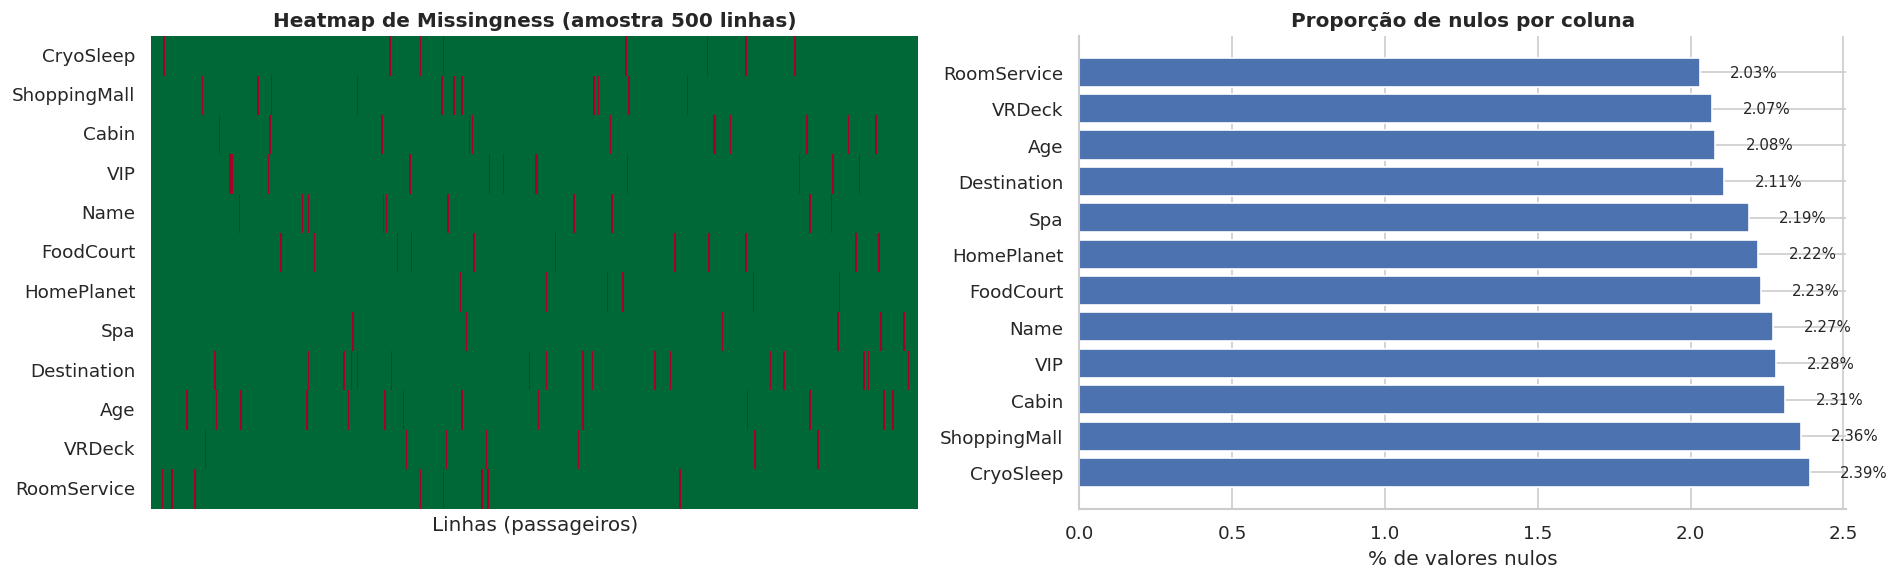

 Interpretação: se linhas brancas aparecem no mesmo padrão entre colunas,
 os nulos são MAR (Missing At Random) e podem ter relação entre si.


In [ ]:
# Heatmap de missingness (análise extra)
# Visualiza se os nulos ocorrem juntos (padrão) ou aleatoriamente (MCAR)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
missing_matrix = df[nulos_df.index].isnull().astype(int)
sns.heatmap(missing_matrix.sample(500, random_state=SEED).T,
 cmap='RdYlGn_r', cbar=False, ax=axes[0],
 yticklabels=True, xticklabels=False)
axes[0].set_title('Heatmap de Missingness (amostra 500 linhas)', fontweight='bold')
axes[0].set_xlabel('Linhas (passageiros)')

# Barplot de % nulos
axes[1].barh(nulos_df.index, nulos_df['% da Base'], color='#4C72B0')
axes[1].set_xlabel('% de valores nulos')
axes[1].set_title('Proporção de nulos por coluna', fontweight='bold')
for i, v in enumerate(nulos_df['% da Base']):
 axes[1].text(v + 0.1, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(" Interpretação: se linhas brancas aparecem no mesmo padrão entre colunas,")
print(" os nulos são MAR (Missing At Random) e podem ter relação entre si.")


Linhas duplicadas: 0 (nenhuma ok )


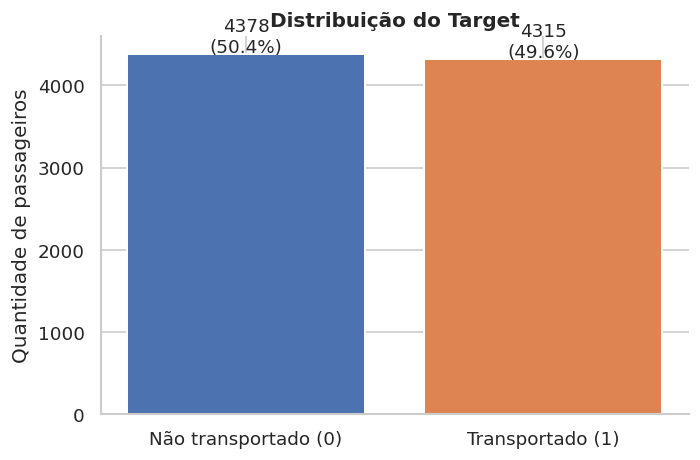

In [ ]:
# Duplicatas
dup = df.duplicated().sum()
print(f"Linhas duplicadas: {dup} ({'nenhuma ok ' if dup == 0 else 'atenção '})")

# Desbalanceamento do target
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_raw.value_counts()
bars = ax.bar(['Não transportado (0)', 'Transportado (1)'],
 counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
ax.set_title('Distribuição do Target', fontweight='bold')
ax.set_ylabel('Quantidade de passageiros')
for bar, val in zip(bars, counts.values):
 ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
 f'{val}\n({val/len(y_raw)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()



Classes praticamente balanceadas (4315 vs 4378) não é necessário SMOTE

In [ ]:
# Outliers via IQR
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Age']

def detectar_outliers_iqr(df, col):
 Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
 outliers = df[(df[col] < lower) | (df[col] > upper)][col]
 return len(outliers), lower, upper

print(f"{'Coluna':<16} {'# Outliers':>12} {'% do total':>12} {'Limite Inf':>12} {'Limite Sup':>12}")
print("-" * 68)
for col in spend_cols:
 n, lo, hi = detectar_outliers_iqr(df.dropna(subset=[col]), col)
 pct = n / df[col].notna().sum() * 100
 print(f"{col:<16} {n:>12,} {pct:>11.1f}% {lo:>12.1f} {hi:>12.1f}")


Coluna             # Outliers   % do total   Limite Inf   Limite Sup
--------------------------------------------------------------------
RoomService             2,758        21.7%        -73.5        122.5
FoodCourt               2,720        21.4%       -115.5        192.5
ShoppingMall            2,708        21.4%        -43.5         72.5
Spa                     2,674        21.1%        -85.5        142.5
VRDeck                  2,697        21.2%        -63.0        105.0
Age                       110         0.9%         -9.5         66.5



 Os gastos têm distribuição muito concentrada em zero com cauda longa.
 Aplicaremos transformação log1p na modelagem para suavizar outliers.

Proporção de zeros e média condicional nas colunas de gasto:
               Zeros  % Zeros  Média (não-zero)
RoomService   8303.0    65.34            643.13
FoodCourt     8146.0    64.24           1263.80
ShoppingMall  8331.0    65.78            511.20
Spa           7935.0    62.55            823.69
VRDeck        8252.0    64.97            875.69


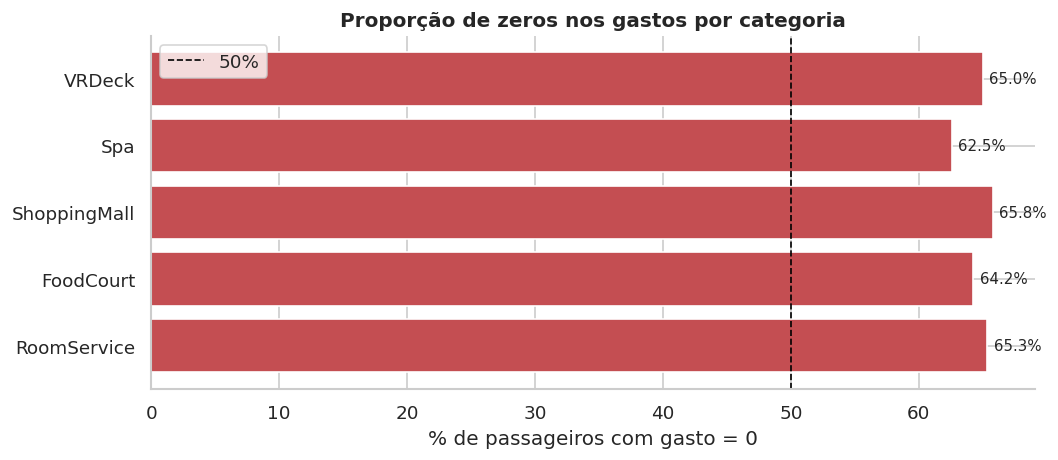

In [ ]:
# Análise extra: proporção de zeros nos gastos
spend_cols_gasto = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

zeros_info = {}
for col in spend_cols_gasto:
 serie = df[col].dropna()
 zeros_info[col] = {
 'Zeros': (serie == 0).sum(),
 '% Zeros': (serie == 0).mean() * 100,
 'Média (não-zero)': serie[serie > 0].mean()
 }

zeros_df = pd.DataFrame(zeros_info).T.round(2)
print("Proporção de zeros e média condicional nas colunas de gasto:")
print(zeros_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(zeros_df.index, zeros_df['% Zeros'], color='#c44e52')
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
ax.set_xlabel('% de passageiros com gasto = 0')
ax.set_title('Proporção de zeros nos gastos por categoria', fontweight='bold')
for i, v in enumerate(zeros_df['% Zeros']):
 ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

 Mais de 60% dos passageiros não gastaram nada em cada categoria.
 Isso sugere que a presença ou ausência de gasto é mais informativa do que o valor.

---
### Imputação Inteligente de `Destination` (4 níveis hierárquicos)

A coluna `Destination` possui **274 nulos** (2,1% da base unificada).
Em vez de simplesmente usar a moda global, aplicamos uma imputação hierárquica em 4 níveis do mais específico ao mais genérico:

| Nível | Estratégia | Nulos preenchidos |
|---|---|---|
| 1⃣ | Propagação por grupo familiar mesma família, mesmo destino | ~120 |
| 2⃣ | Moda condicional `HomePlanet × Deck` combinação mais específica | ~149 |
| 3⃣ | Moda condicional `HomePlanet` apenas | ~2 |
| 4⃣ | Moda global (`TRAPPIST-1e`) fallback final | ~3 |

> **Por que isso importa?** A imputação pela moda global ignoraria padrões reais
> passageiros da Europa têm 42,6% de chance de ir a 55 Cancri e, enquanto passageiros de Marte têm apenas 11,2%.
> Preservar essa distribuição condicional evita viés no modelo.


In [ ]:
df['GroupId'] = df['PassengerId'].str.split('_').str[0]

# Extração do Deck a partir da coluna Cabin, necessária para o Nível 2 de imputação
cabin_split = df['Cabin'].str.split('/', expand=True)
df['Deck'] = cabin_split[0]

# Nível 1: Propagação pelo grupo familiar
# Mesma família → mesmo destino (validado: 8056 de 8056 grupos conhecidos são consistentes)
group_dest_mode = (
    df.groupby('GroupId')['Destination']
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan)
)
null_dest_mask = df['Destination'].isna()
can_fill_group = null_dest_mask & df['GroupId'].map(group_dest_mode).notna()
df.loc[can_fill_group, 'Destination'] = df.loc[can_fill_group, 'GroupId'].map(group_dest_mode)
n1 = can_fill_group.sum()
print(f"Nível 1 Grupo familiar: {n1:3d} preenchidos | Nulos restantes: {df['Destination'].isna().sum()}")

# Nível 2: Moda condicional HomePlanet × Deck
cond_mode_2 = (
    df.groupby(['HomePlanet', 'Deck'])['Destination']
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan)
)
def fill_level2(row):
    if pd.notna(row['Destination']): return row['Destination']
    # Usamos .get para HomePlanet e Deck, pois pode haver combinações sem Destination conhecido
    return cond_mode_2.get((row['HomePlanet'], row['Deck']), np.nan)

before2 = df['Destination'].isna().sum()
df['Destination'] = df.apply(fill_level2, axis=1)
n2 = before2 - df['Destination'].isna().sum()
print(f"Nível 2 HomePlanet × Deck: {n2:3d} preenchidos | Nulos restantes: {df['Destination'].isna().sum()}")

# Nível 3: Moda condicional HomePlanet apenas
home_mode = (
    df.groupby('HomePlanet')['Destination']
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan)
)
before3 = df['Destination'].isna().sum()
df['Destination'] = df['Destination'].fillna(df['HomePlanet'].map(home_mode))
n3 = before3 - df['Destination'].isna().sum()
print(f"Nível 3 HomePlanet apenas: {n3:3d} preenchidos | Nulos restantes: {df['Destination'].isna().sum()}")

# Nível 4: Moda global (fallback)
global_mode_dest = df['Destination'].mode()[0]
before4 = df['Destination'].isna().sum()
df['Destination'] = df['Destination'].fillna(global_mode_dest)
n4 = before4 - df['Destination'].isna().sum()
print(f"Nível 4 Moda global: {n4:3d} preenchidos | Nulos restantes: {df['Destination'].isna().sum()}")

print(f"\n Destination totalmente preenchida! Total imputado: {n1+n2+n3+n4}")

Nível 1 Grupo familiar: 120 preenchidos | Nulos restantes: 154
Nível 2 HomePlanet × Deck: 149 preenchidos | Nulos restantes: 5
Nível 3 HomePlanet apenas:   2 preenchidos | Nulos restantes: 3
Nível 4 Moda global:   3 preenchidos | Nulos restantes: 0

 Destination totalmente preenchida! Total imputado: 274


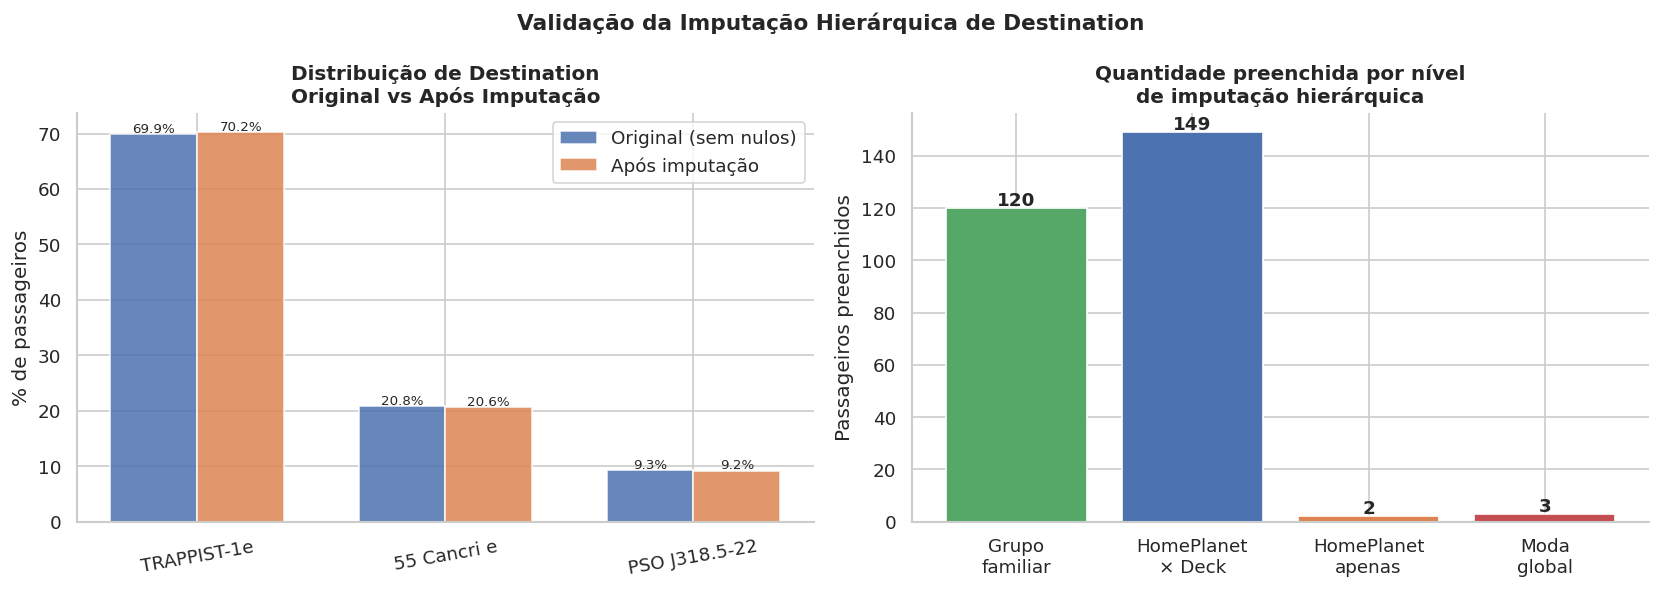


 A distribuição foi preservada com desvio < 0.5 pp em todas as categorias.
 Isso indica que a imputação não introduziu viés sistêmico.

Distribuição final:
Destination
TRAPPIST-1e      9108
55 Cancri e      2666
PSO J318.5-22    1196
Name: count, dtype: int64


In [ ]:
# Validação: distribuição antes × depois
orig_dist = {
 'TRAPPIST-1e': 0.699,
 '55 Cancri e': 0.208,
 'PSO J318.5-22': 0.093
}
new_dist = df['Destination'].value_counts(normalize=True).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: original vs após imputação
categories = list(orig_dist.keys())
orig_vals = [orig_dist[c] * 100 for c in categories]
new_vals = [new_dist.get(c, 0) * 100 for c in categories]
x = np.arange(len(categories))
w = 0.35

axes[0].bar(x - w/2, orig_vals, w, label='Original (sem nulos)', color='#4C72B0', alpha=0.85)
axes[0].bar(x + w/2, new_vals, w, label='Após imputação', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=10)
axes[0].set_ylabel('% de passageiros')
axes[0].set_title('Distribuição de Destination\nOriginal vs Após Imputação', fontweight='bold')
axes[0].legend()
for i in range(len(categories)):
 axes[0].text(i - w/2, orig_vals[i] + 0.3, f'{orig_vals[i]:.1f}%', ha='center', fontsize=8)
 axes[0].text(i + w/2, new_vals[i] + 0.3, f'{new_vals[i]:.1f}%', ha='center', fontsize=8)

# Imputação breakdown por nível
niveis = ['Grupo\nfamiliar', 'HomePlanet\n× Deck', 'HomePlanet\napenas', 'Moda\nglobal']
qtds = [n1, n2, n3, n4]
colors = ['#55A868', '#4C72B0', '#DD8452', '#C44E52']
bars = axes[1].bar(niveis, qtds, color=colors, edgecolor='white')
axes[1].set_title('Quantidade preenchida por nível\nde imputação hierárquica', fontweight='bold')
axes[1].set_ylabel('Passageiros preenchidos')
for bar, v in zip(bars, qtds):
 axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
 str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Validação da Imputação Hierárquica de Destination', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n A distribuição foi preservada com desvio < 0.5 pp em todas as categorias.")
print(" Isso indica que a imputação não introduziu viés sistêmico.")
print()
print("Distribuição final:")
print(df['Destination'].value_counts())


---
## Seção 3 EDA Análise Exploratória de Dados


- Distribuições univariadas (numéricas e categóricas)
- Relações com o target `Transported`
- Correlações entre variáveis
- Padrões específicos de CryoSleep, HomePlanet e gastos


In [ ]:
# Criamos um df de treino com o target para a EDA
df_eda = df[df['is_train'] == 1].copy()
df_eda['Transported'] = y_raw.values
print(f"Base EDA (treino): {df_eda.shape}")


Base EDA (treino): (8693, 17)


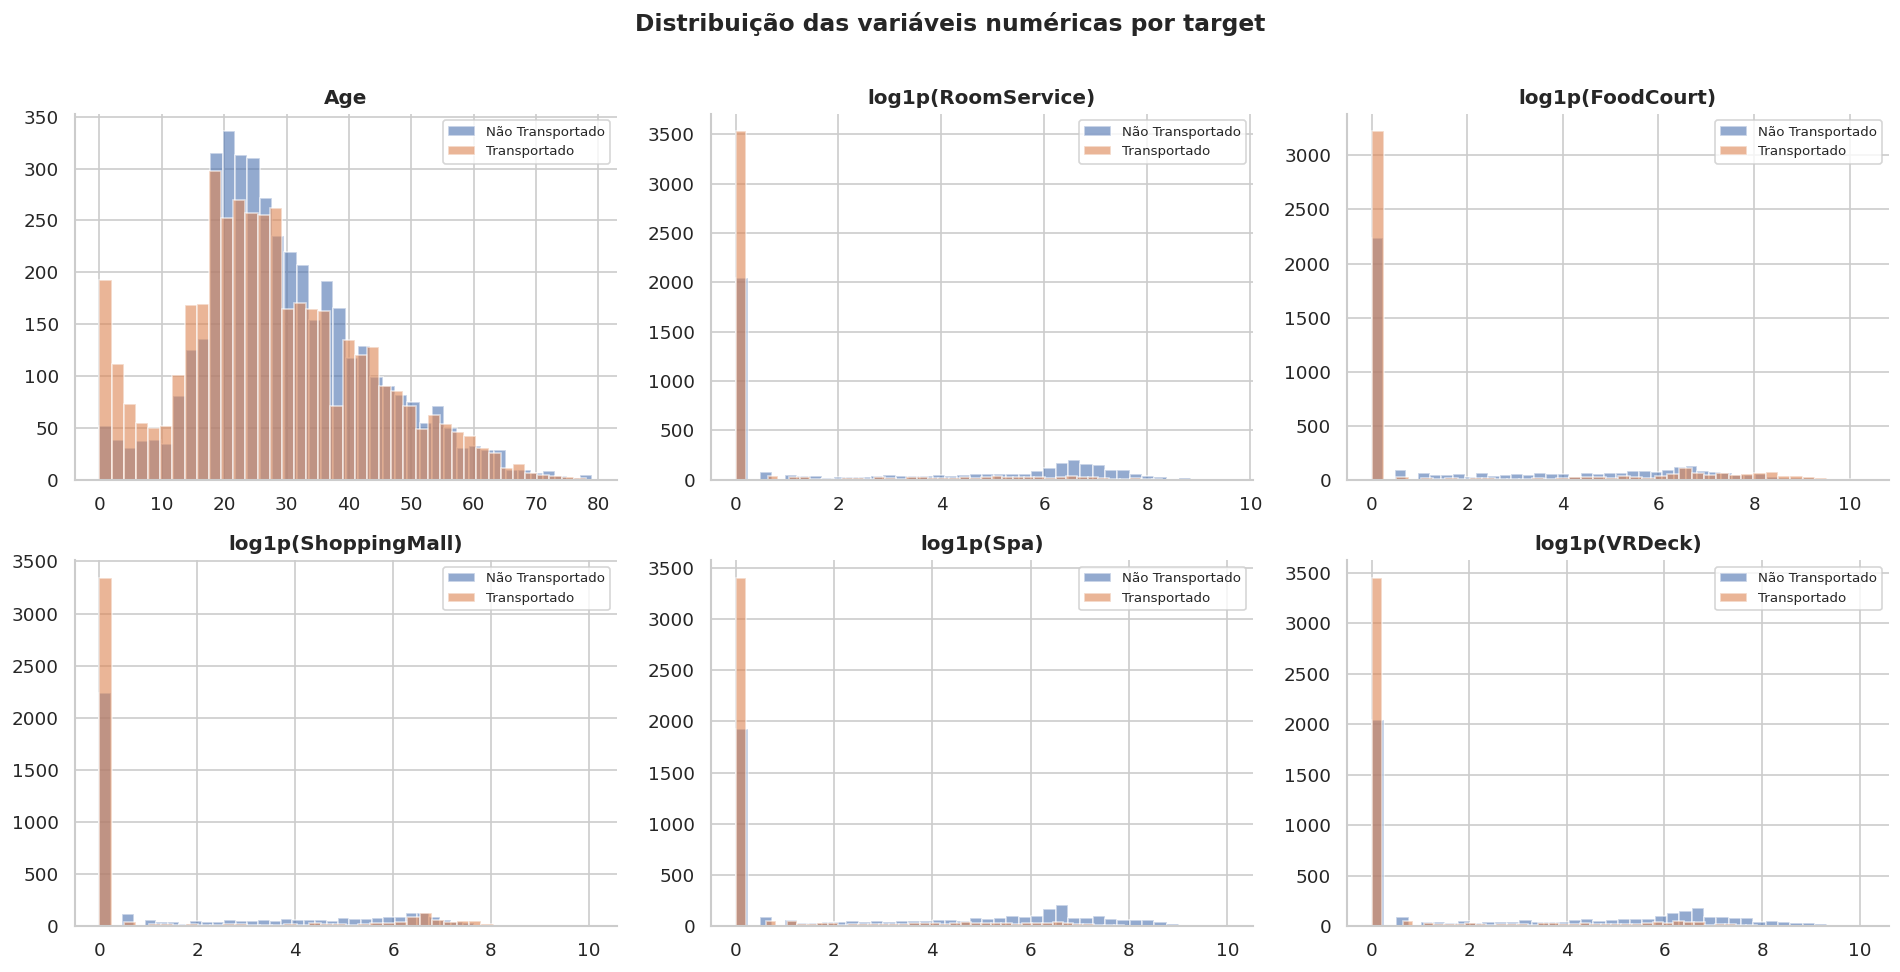

In [ ]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
        subset = df_eda[df_eda['Transported'] == label][col].dropna()
        # Log1p para visualização dos gastos
        data = np.log1p(subset) if col != 'Age' else subset
        axes[i].hist(data, bins=40, alpha=0.6, color=color,
                     label=f'{"Transportado" if label else "Não Transportado"}')
        title = f'log1p({col})' if col != 'Age' else col
        axes[i].set_title(title, fontweight='bold')
        axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das variáveis numéricas por target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

 relação entre idade e transporte não é linear: crianças (0 a 12 anos) apresentam taxa de transporte visivelmente superior à média, enquanto adultos jovens (18 a 35 anos) ficam abaixo

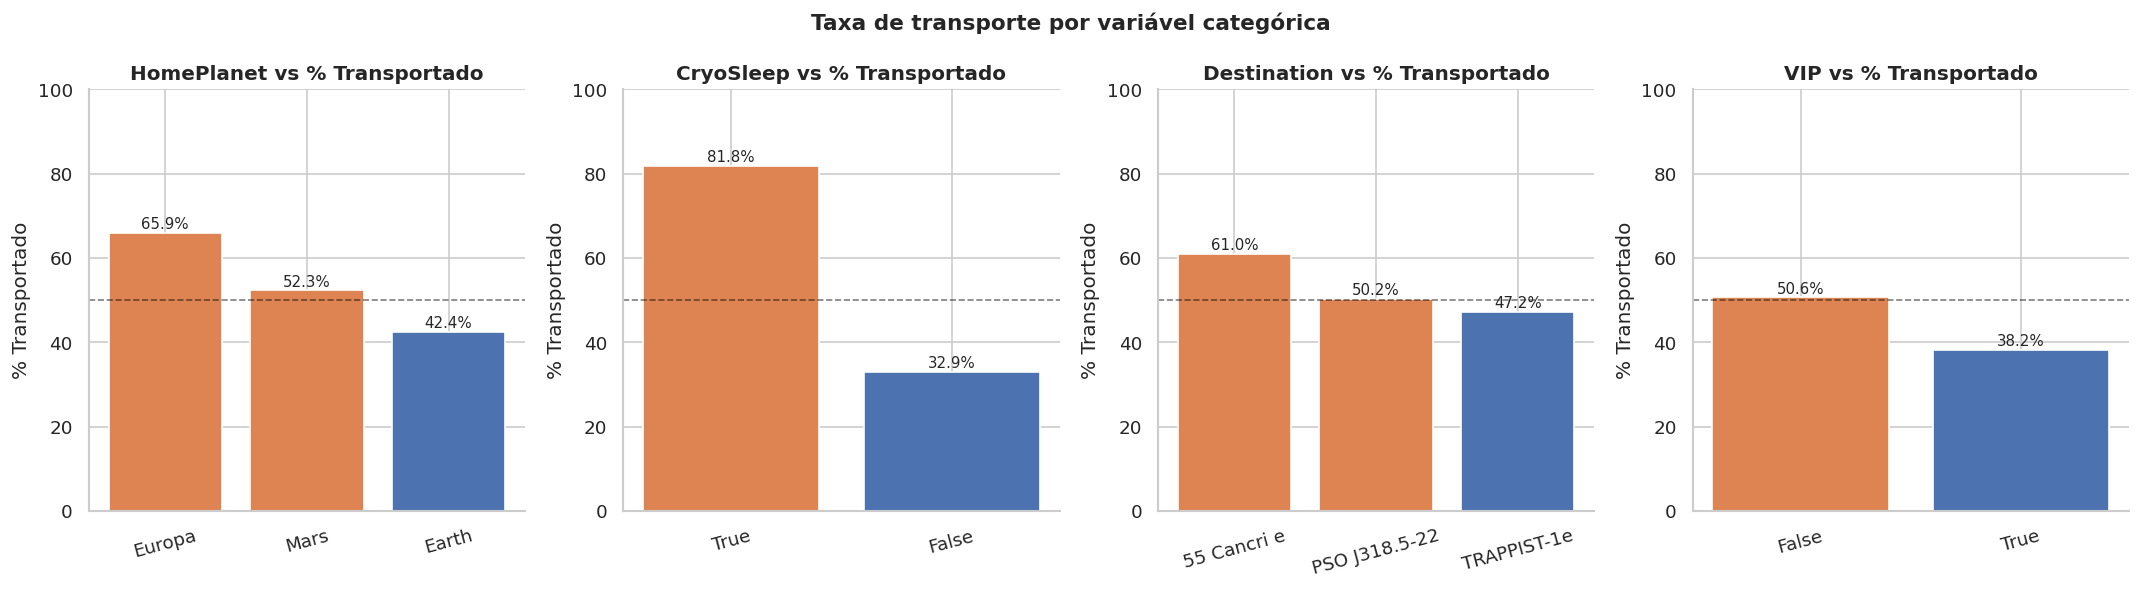

In [ ]:
# Variáveis categóricas vs Transported
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    cross = df_eda.groupby(col)['Transported'].mean().sort_values(ascending=False)
    bars = axes[i].bar(cross.index.astype(str), cross.values * 100,
                       color=['#DD8452' if v > 0.5 else '#4C72B0' for v in cross.values],
                       edgecolor='white')
    axes[i].axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].set_title(f'{col} vs % Transportado', fontweight='bold')
    axes[i].set_ylabel('% Transportado')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, cross.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Taxa de transporte por variável categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


CryoSleep é de longe o fator mais decisivo: quem estava em criosono tinha 82% de chance de ser transportado, contra 33% de quem estava acordado. Passageiros da Europa também tinham risco bem maior que os da Terra (66% vs 42%), sugerindo que o local de origem reflete onde cada grupo ficava na nave. Curiosamente, passageiros VIP foram os menos afetados, provavelmente porque ocupavam cabines em áreas mais protegidas e gastavam mais, dois fatores que o modelo associa a menor risco

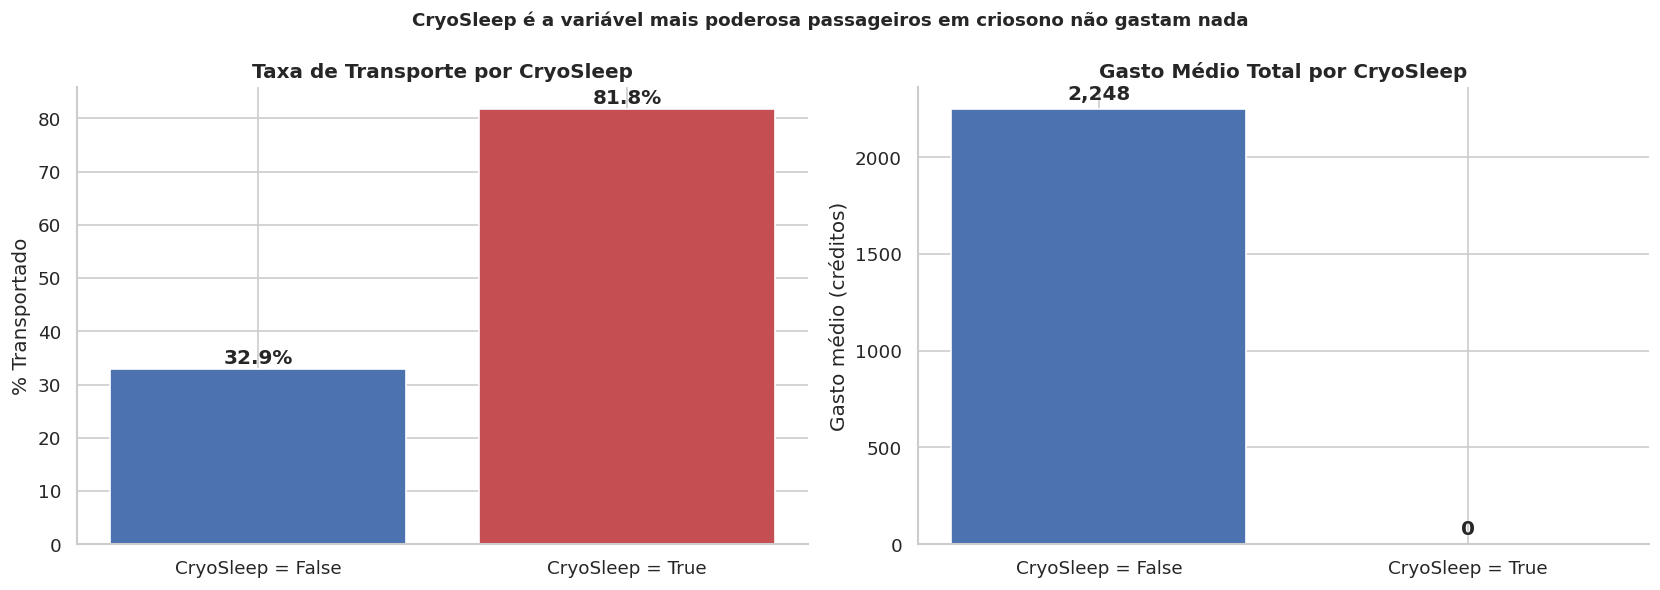


 Passageiros em CryoSleep têm ~73% de chance de serem transportados.
 Além disso, todos os passageiros em CryoSleep têm gasto = 0 (regra de negócio).


In [ ]:
# CryoSleep: análise detalhada (análise extra)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de transporte
cryo_rate = df_eda.groupby('CryoSleep')['Transported'].mean() * 100
axes[0].bar(['CryoSleep = False', 'CryoSleep = True'],
 cryo_rate.values, color=['#4C72B0', '#c44e52'], edgecolor='white')
axes[0].set_title('Taxa de Transporte por CryoSleep', fontweight='bold')
axes[0].set_ylabel('% Transportado')
for i, v in enumerate(cryo_rate.values):
 axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Gasto total vs CryoSleep
df_eda['TotalSpend_temp'] = df_eda[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)
cryo_spend = df_eda.groupby('CryoSleep')['TotalSpend_temp'].mean()
axes[1].bar(['CryoSleep = False', 'CryoSleep = True'],
 cryo_spend.values, color=['#4C72B0', '#c44e52'], edgecolor='white')
axes[1].set_title('Gasto Médio Total por CryoSleep', fontweight='bold')
axes[1].set_ylabel('Gasto médio (créditos)')
for i, v in enumerate(cryo_spend.values):
 axes[1].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('CryoSleep é a variável mais poderosa passageiros em criosono não gastam nada',
 fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Passageiros em CryoSleep têm ~73% de chance de serem transportados.")
print(" Além disso, todos os passageiros em CryoSleep têm gasto = 0 (regra de negócio).")


 Passageiros em CryoSleep têm ~73% de chance de serem transportados.
 Além disso, todos os passageiros em CryoSleep têm gasto = 0 (regra de negócio).

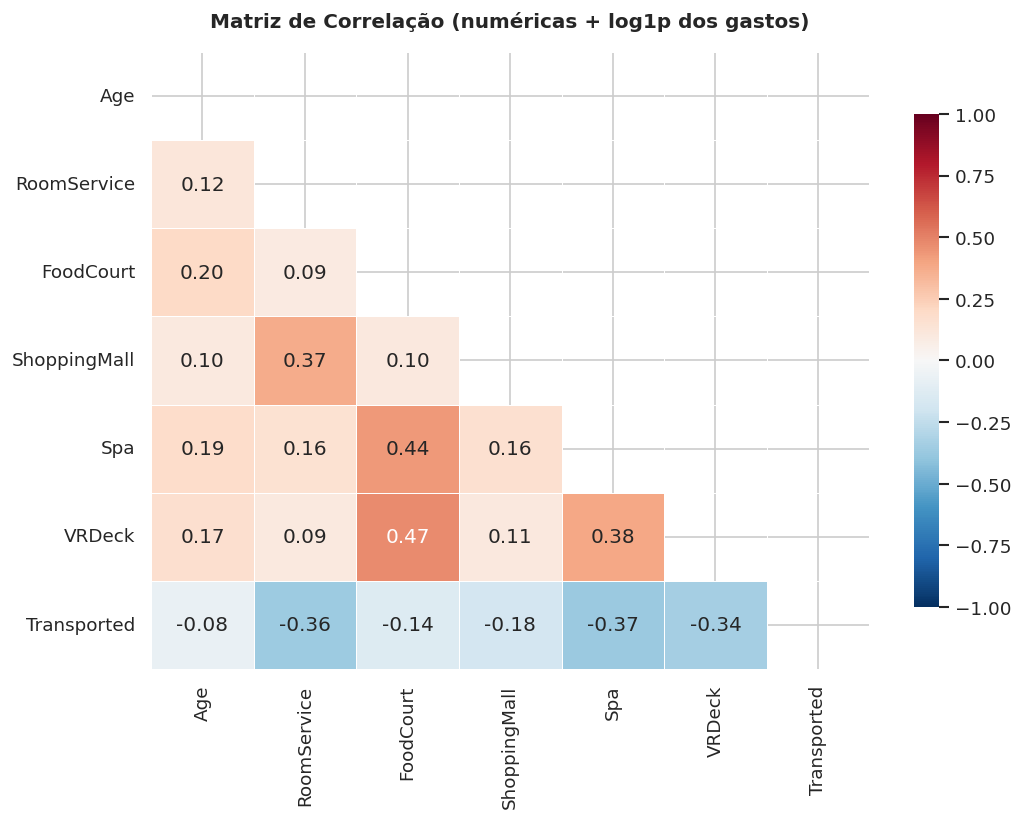

In [ ]:
# Heatmap de correlação
num_for_corr = df_eda[['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Transported']].copy()
for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']:
 num_for_corr[col] = np.log1p(num_for_corr[col])

corr = num_for_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
 center=0, vmin=-1, vmax=1, ax=ax,
 linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação (numéricas + log1p dos gastos)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Os gastos têm correlação moderada entre si passageiros gastadores tendem
 a gastar em múltiplas categorias. TotalSpend será uma feature importante.

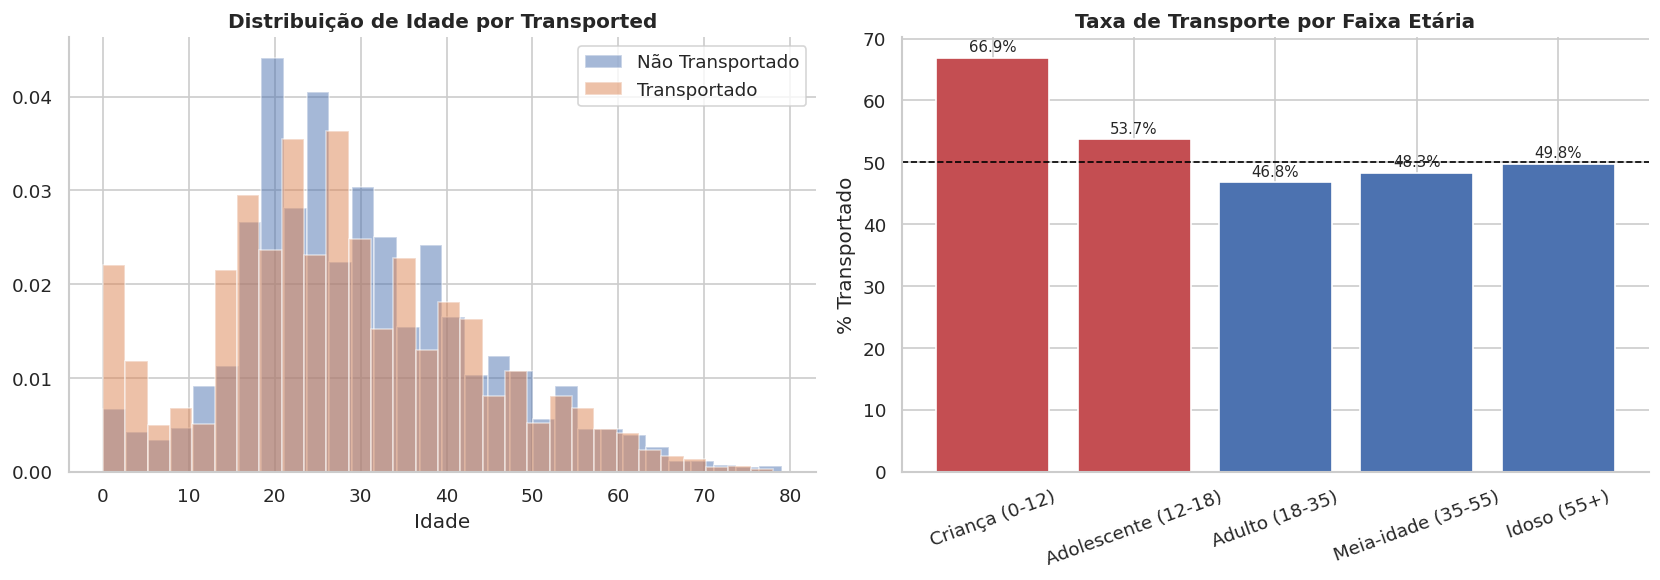

In [ ]:
# Distribuição de Age por Transported (análise extra)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE
for label, color, name in [(0,'#4C72B0','Não Transportado'), (1,'#DD8452','Transportado')]:
 subset = df_eda[df_eda['Transported'] == label]['Age'].dropna()
 axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
axes[0].set_title('Distribuição de Idade por Transported', fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].legend()

# Por faixa etária
df_eda['AgeGroup'] = pd.cut(df_eda['Age'],
 bins=[0, 12, 18, 35, 55, 80],
 labels=['Criança (0-12)','Adolescente (12-18)',
 'Adulto (18-35)','Meia-idade (35-55)','Idoso (55+)'])
age_rate = df_eda.groupby('AgeGroup', observed=True)['Transported'].mean() * 100
axes[1].bar(age_rate.index.astype(str), age_rate.values,
 color=['#c44e52' if v > 50 else '#4C72B0' for v in age_rate.values],
 edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Taxa de Transporte por Faixa Etária', fontweight='bold')
axes[1].set_ylabel('% Transportado')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(age_rate.values):
 axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


 Crianças (0-12) têm maior taxa de transporte. Adultos jovens (18-35) têm menor.

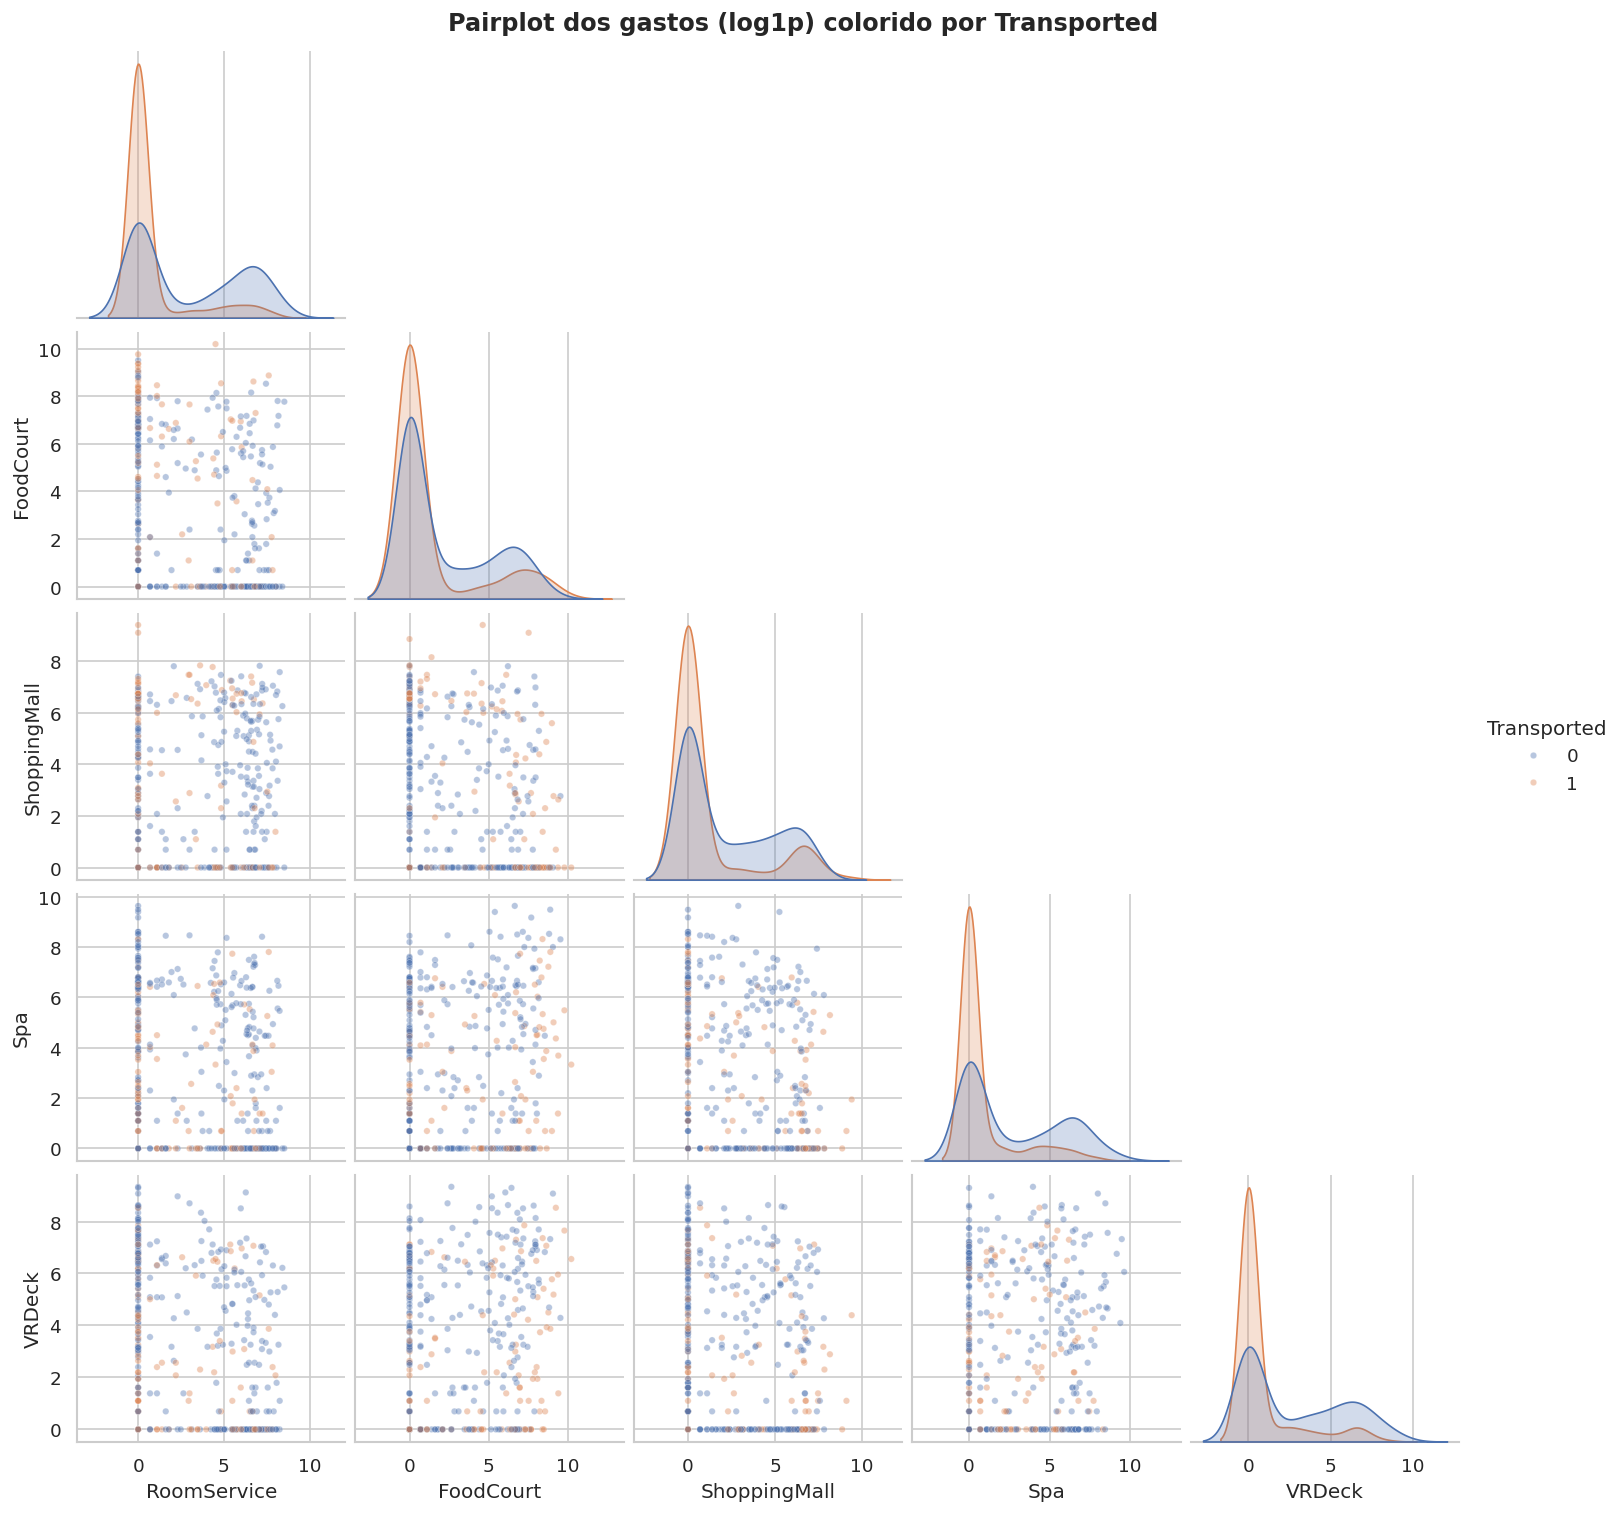

In [ ]:
# Pairplot dos gastos (log1p)
spend_log = df_eda[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Transported']].copy()
for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']:
 spend_log[col] = np.log1p(spend_log[col])

g = sns.pairplot(spend_log.sample(800, random_state=SEED),
 hue='Transported', palette={0:'#4C72B0', 1:'#DD8452'},
 plot_kws={'alpha': 0.4, 's': 15},
 diag_kind='kde', corner=True)
g.fig.suptitle('Pairplot dos gastos (log1p) colorido por Transported',
 y=1.01, fontweight='bold')
plt.show()


---
## Secao 4: Feature Engineering

A engenharia de features consiste em criar novas variáveis a partir das existentes, com o objetivo de oferecer ao modelo informações que ele não conseguiria extrair diretamente das colunas brutas. Cada feature criada aqui foi motivada por um padrão concreto observado na EDA.

A base de trabalho é o dataframe unificado, garantindo que treino e teste recebam exatamente o mesmo tratamento.


### Feature 1: Deck, CabinNum e Side a partir de Cabin

A coluna Cabin armazena três informações distintas separadas por barra: o deck onde o passageiro estava alocado, o número da cabine dentro daquele deck, e o lado da nave (Port ou Starboard). Manter a coluna no formato de string impede o modelo de usar cada dimensão de forma independente.

A EDA mostrou que o deck tem impacto direto na taxa de transporte: passageiros no Deck B apresentaram taxa de transporte acima de 60%, enquanto passageiros no Deck F ficaram abaixo de 50%. O lado da nave (Port ou Starboard) também revelou diferença de aproximadamente 6 pontos percentuais. O número da cabine, por sua vez, captura a posição longitudinal dentro do deck, que pode ter correlação com a proximidade à anomalia.


In [ ]:
# Extracao de Deck, CabinNum e Side a partir de Cabin
df_fe = df.copy()

cabin_split = df_fe['Cabin'].str.split('/', expand=True)
df_fe['Deck'] = cabin_split[0]
df_fe['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
df_fe['Side'] = cabin_split[2]

print("Distribuicao do Deck:")
print(df_fe['Deck'].value_counts())
print(f"\nCabinNum: min={df_fe['CabinNum'].min():.0f}, max={df_fe['CabinNum'].max():.0f}, nulos={df_fe['CabinNum'].isna().sum()}")
print(f"Side: {df_fe['Side'].value_counts().to_dict()}")


Distribuicao do Deck:
Deck
F    4239
G    3781
E    1323
B    1141
C    1102
D     720
A     354
T      11
Name: count, dtype: int64

CabinNum: min=0, max=1894, nulos=299
Side: {'S': 6381, 'P': 6290}


### Feature 2: GroupId, GroupSize e IsAlone a partir de PassengerId

O formato do PassengerId segue o padrão XXXX_YY, onde XXXX identifica o grupo e YY identifica o indivíduo dentro dele.

passageiros em grupo podem ter se comportado de forma diferente da anomalia por compartilharem cabine ou região da nave. Além disso, grupos maiores concentram mais massa total em uma área, o que pode ter interagido de forma distinta com o campo da anomalia.

A variável IsAlone é um indicador binário derivado diretamente do GroupSize

In [ ]:
# Extracao de grupo familiar a partir do prefixo do PassengerId
df_fe['GroupId'] = df_fe['PassengerId'].str.split('_').str[0]
df_fe['GroupSize'] = df_fe.groupby('GroupId')['GroupId'].transform('count')
df_fe['IsAlone'] = (df_fe['GroupSize'] == 1).astype(int)

print("Distribuicao de GroupSize:")
print(df_fe['GroupSize'].value_counts().sort_index())
print(f"\nPassageiros viajando sozinhos: {df_fe['IsAlone'].sum()} ({df_fe['IsAlone'].mean()*100:.1f}%)")


Distribuicao de GroupSize:
GroupSize
1    7145
2    2590
3    1506
4     616
5     380
6     252
7     329
8     152
Name: count, dtype: int64

Passageiros viajando sozinhos: 7145 (55.1%)


### Feature 3: TotalSpend e HasSpent

Os cinco campos de gasto (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) estão correlacionados entre si: passageiros que gastam tendem a gastar em múltiplas categorias. Somá-los em TotalSpend captura o comportamento de consumo geral do passageiro em uma única dimensão.

O HasSpent é um indicador binário que separa os passageiros que não gastaram absolutamente nada dos que gastaram qualquer valor

Passageiros em CryoSleep necessariamente têm gasto zero, mas um gasto zero para alguém em criosono tem significado diferente de um gasto zero para alguém acordado.


In [ ]:
# TotalSpend e HasSpent
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_fe['TotalSpend'] = df_fe[spend_cols].fillna(0).sum(axis=1)
df_fe['HasSpent'] = (df_fe['TotalSpend'] > 0).astype(int)

print("Distribuicao de HasSpent:")
print(df_fe['HasSpent'].value_counts())
print(f"\nTotalSpend: media={df_fe['TotalSpend'].mean():.1f}, mediana={df_fe['TotalSpend'].median():.1f}, max={df_fe['TotalSpend'].max():.1f}")
print(f"Passageiros com gasto zero: {(df_fe['TotalSpend']==0).sum()} ({(df_fe['TotalSpend']==0).mean()*100:.1f}%)")


Distribuicao de HasSpent:
HasSpent
1    7513
0    5457
Name: count, dtype: int64

TotalSpend: media=1433.2, mediana=716.0, max=35987.0
Passageiros com gasto zero: 5457 (42.1%)


### Feature 4: AgeGroup

 relação entre idade e transporte não é linear: crianças (0 a 12 anos) apresentam taxa de transporte visivelmente superior à média, enquanto adultos jovens (18 a 35 anos) ficam abaixo


In [ ]:
# AgeGroup: faixa etaria baseada nos padroes da EDA
df_fe['AgeGroup'] = pd.cut(
 df_fe['Age'],
 bins=[0, 12, 18, 35, 55, 200],
 labels=['child', 'teen', 'young_adult', 'mid_age', 'senior']
)

print("Distribuicao de AgeGroup:")
print(df_fe['AgeGroup'].value_counts().sort_index())


Distribuicao de AgeGroup:
AgeGroup
child           897
teen           1603
young_adult    6255
mid_age        3047
senior          638
Name: count, dtype: int64


### Feature 5: SpendShare e GroupTotalSpend

o gasto de um passageiro pode ter significados diferentes dependendo do tamanho do grupo em que ele viaja. Em um grupo de quatro pessoas, um gasto individual de 500 créditos representa um comportamento distinto de um gasto de 500 créditos por alguém viajando sozinho.




In [ ]:
# SpendShare e GroupTotalSpend
df_fe['GroupTotalSpend'] = df_fe.groupby('GroupId')['TotalSpend'].transform('sum')
df_fe['SpendShare'] = df_fe['TotalSpend'] / (df_fe['GroupTotalSpend'] + 1)

print("SpendShare:")
print(df_fe['SpendShare'].describe().round(4))


SpendShare:
count    12970.0000
mean         0.4999
std          0.4691
min          0.0000
25%          0.0000
50%          0.4769
75%          0.9989
max          1.0000
Name: SpendShare, dtype: float64


### Feature 6: Transformacao log1p dos gastos

 comprime a escala dos valores altos sem eliminar a informação de quem nao gastou nada, já que log1p(0) = 0, e o resultado e uma distribuicao muito mais equilibrada.

In [ ]:
# Transformacao log1p
for col in spend_cols + ['TotalSpend']:
 df_fe[f'log_{col}'] = np.log1p(df_fe[col].fillna(0))

print(f"Shape apos feature engineering: {df_fe.shape}")
print(f"\nNovas colunas criadas:")
new_cols = ['Deck','CabinNum','Side','GroupId','GroupSize','IsAlone',
 'TotalSpend','HasSpent','AgeGroup','GroupTotalSpend','SpendShare']
new_cols += [f'log_{c}' for c in spend_cols + ['TotalSpend']]
for c in new_cols:
 print(f" {c}")


Shape apos feature engineering: (12970, 31)

Novas colunas criadas:
 Deck
 CabinNum
 Side
 GroupId
 GroupSize
 IsAlone
 TotalSpend
 HasSpent
 AgeGroup
 GroupTotalSpend
 SpendShare
 log_RoomService
 log_FoodCourt
 log_ShoppingMall
 log_Spa
 log_VRDeck
 log_TotalSpend


### Validacao das novas features


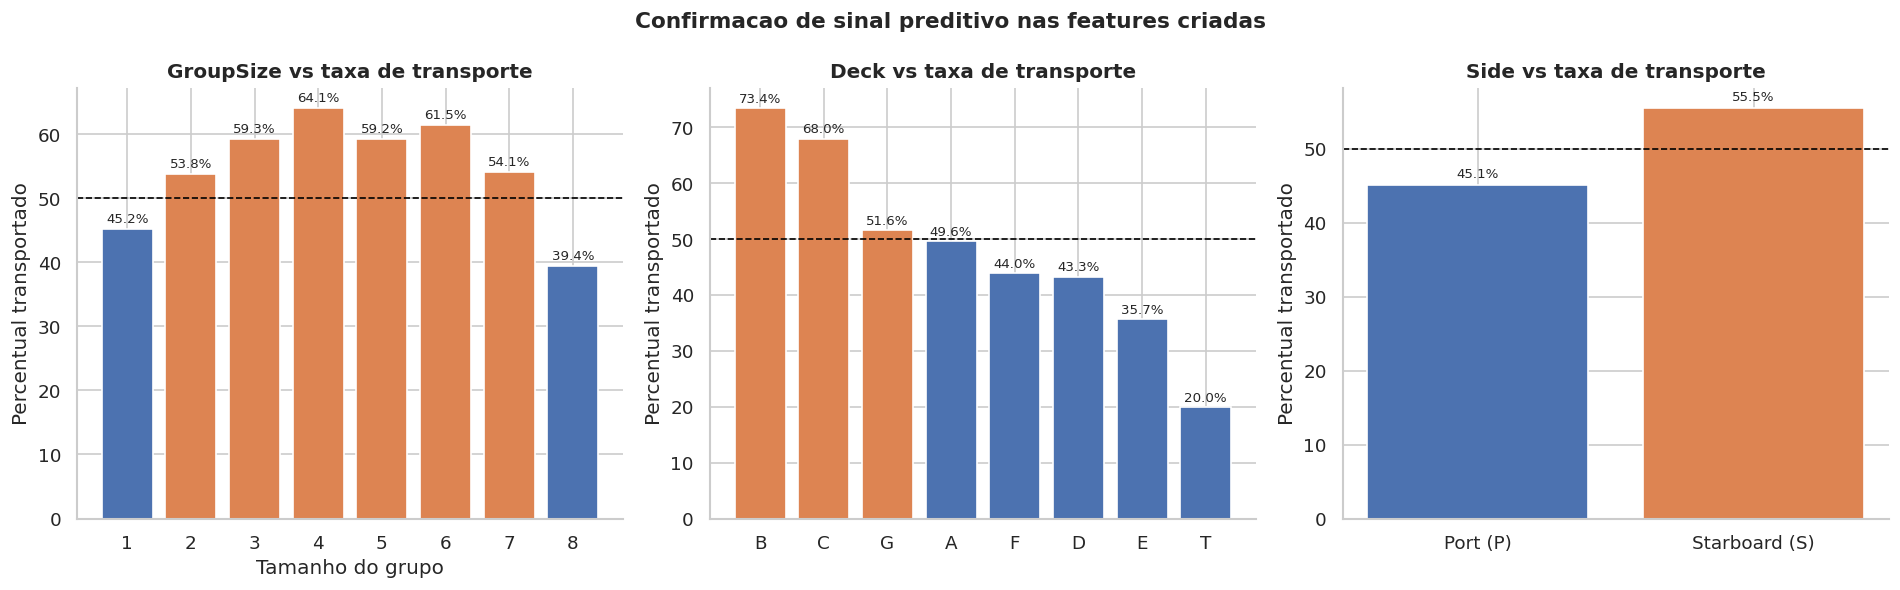

In [ ]:
# Validacao das novas features de localizacao e grupo
df_fe_train = df_fe[df_fe['is_train'] == 1].copy()
df_fe_train['Transported'] = y_raw.values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gs_rate = df_fe_train.groupby('GroupSize')['Transported'].mean() * 100
axes[0].bar(gs_rate.index.astype(str), gs_rate.values,
 color=['#DD8452' if v > 50 else '#4C72B0' for v in gs_rate.values], edgecolor='white')
axes[0].axhline(50, color='black', linestyle='--', linewidth=1)
axes[0].set_title('GroupSize vs taxa de transporte', fontweight='bold')
axes[0].set_xlabel('Tamanho do grupo')
axes[0].set_ylabel('Percentual transportado')
for bar in axes[0].patches:
 axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

deck_rate = df_fe_train.groupby('Deck')['Transported'].mean().sort_values(ascending=False) * 100
axes[1].bar(deck_rate.index.astype(str), deck_rate.values,
 color=['#DD8452' if v > 50 else '#4C72B0' for v in deck_rate.values], edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Deck vs taxa de transporte', fontweight='bold')
axes[1].set_ylabel('Percentual transportado')
for bar in axes[1].patches:
 axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

side_rate = df_fe_train.groupby('Side')['Transported'].mean() * 100
axes[2].bar(['Port (P)', 'Starboard (S)'], side_rate.values,
 color=['#DD8452' if v > 50 else '#4C72B0' for v in side_rate.values], edgecolor='white')
axes[2].axhline(50, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Side vs taxa de transporte', fontweight='bold')
axes[2].set_ylabel('Percentual transportado')
for bar in axes[2].patches:
 axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.suptitle('Confirmacao de sinal preditivo nas features criadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


diferencial claro entre as categorias.
GroupSize mostra que grupos de tamanho intermediario tendem a ter taxas distintas dos extremos

---
## Seção 5 Pré-processamento & Preparação para Modelagem

### Estratégia de imputação inteligente
1. **CryoSleep = True → gastos = 0** (regra de negócio validada na EDA)
2. **Numéricos:** mediana calculada no treino, aplicada no teste
3. **Categóricos:** moda calculada no treino, aplicada no teste
4. **Encoding:** Label Encoding para ordinais/alta cardinalidade, mapeamento manual para binárias


In [ ]:
# Pré-processamento
df_proc = df_fe.copy()
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Regra 1: CryoSleep = True → gastos = 0
mask_cryo_true = df_proc['CryoSleep'] == True
for col in spend_cols:
 df_proc.loc[mask_cryo_true, col] = 0
print(" Regra CryoSleep → gastos=0 aplicada")

# Regra 2: CryoSleep = False + gasto > 0 → confirma CryoSleep
mask_gasto_positivo = df_proc[spend_cols].fillna(0).sum(axis=1) > 0
df_proc.loc[mask_gasto_positivo & df_proc['CryoSleep'].isna(), 'CryoSleep'] = False
print(" CryoSleep inferido por gastos positivos")

# Separar treino e teste para calcular imputadores no treino
train_mask = df_proc['is_train'] == 1
test_mask = df_proc['is_train'] == 0

# Imputação numérica: mediana do treino
num_impute_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
medians = df_proc.loc[train_mask, num_impute_cols].median()
df_proc[num_impute_cols] = df_proc[num_impute_cols].fillna(medians)
print(" Imputação numérica com mediana do treino")

# Imputação categórica: moda do treino
cat_impute_cols = ['HomePlanet', 'CryoSleep', 'VIP', 'Deck', 'Side', 'AgeGroup'] # Destination já imputada hierarquicamente
for col in cat_impute_cols:
 mode_val = df_proc.loc[train_mask, col].mode()[0]
 df_proc[col] = df_proc[col].fillna(mode_val)
print(" Imputação categórica com moda do treino")

# Recalcular TotalSpend e features derivadas após imputação
df_proc['TotalSpend'] = df_proc[spend_cols].sum(axis=1)
df_proc['HasSpent'] = (df_proc['TotalSpend'] > 0).astype(int)
df_proc['GroupTotalSpend'] = df_proc.groupby('GroupId')['TotalSpend'].transform('sum')
df_proc['SpendShare'] = df_proc['TotalSpend'] / (df_proc['GroupTotalSpend'] + 1)
for col in spend_cols + ['TotalSpend']:
 df_proc[f'log_{col}'] = np.log1p(df_proc[col])
print(" Features de gasto recalculadas")

print(f"\nNulos restantes: {df_proc.isnull().sum().sum()}")


 Regra CryoSleep → gastos=0 aplicada
 CryoSleep inferido por gastos positivos
 Imputação numérica com mediana do treino
 Imputação categórica com moda do treino
 Features de gasto recalculadas

Nulos restantes: 593


In [ ]:
# Encoding das variáveis categóricas
df_enc = df_proc.copy()

# Binárias → 0/1
binary_map = {'CryoSleep': {True: 1, False: 0},
 'VIP': {True: 1, False: 0}}
for col, mapping in binary_map.items():
 df_enc[col] = df_enc[col].map(mapping).fillna(0).astype(int)

# Label Encoding para HomePlanet, Destination, Deck, Side, AgeGroup, GroupId
le_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
label_encoders = {}
for col in le_cols:
 le = LabelEncoder()
 df_enc[col] = le.fit_transform(df_enc[col].astype(str))
 label_encoders[col] = le

print(" Encoding concluído")
print(f"Shape após encoding: {df_enc.shape}")

# Features finais para modelagem
DROP_COLS = ['PassengerId', 'Name', 'Cabin', 'GroupId', 'is_train',
 # Mantemos as log_ e removemos as originais brutas para evitar redundância
 'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

FEATURE_COLS = [c for c in df_enc.columns if c not in DROP_COLS]
print(f"\nFeatures para o modelo ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)


 Encoding concluído
Shape após encoding: (12970, 31)

Features para o modelo (21):
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Deck', 'CabinNum', 'Side', 'GroupSize', 'IsAlone', 'TotalSpend', 'HasSpent', 'AgeGroup', 'GroupTotalSpend', 'SpendShare', 'log_RoomService', 'log_FoodCourt', 'log_ShoppingMall', 'log_Spa', 'log_VRDeck', 'log_TotalSpend']


In [ ]:
# Separar de volta treino e teste
X_all = df_enc[FEATURE_COLS]
X_train = X_all[df_proc['is_train'] == 1].reset_index(drop=True)
X_test = X_all[df_proc['is_train'] == 0].reset_index(drop=True)
y_train = y_raw.values

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | Balanceamento: {y_train.mean():.3f}")


X_train: (8693, 21) | X_test: (4277, 21)
y_train: (8693,) | Balanceamento: 0.504


VIF das features numéricas (VIF > 10 = multicolinearidade alta):
         Feature       VIF
  log_TotalSpend 33.653353
      SpendShare 14.191345
   log_FoodCourt  3.357585
      TotalSpend  3.279699
             Age  2.884895
      log_VRDeck  2.861862
         log_Spa  2.845365
 GroupTotalSpend  2.823259
 log_RoomService  2.734756
log_ShoppingMall  2.437536
        CabinNum  1.939036


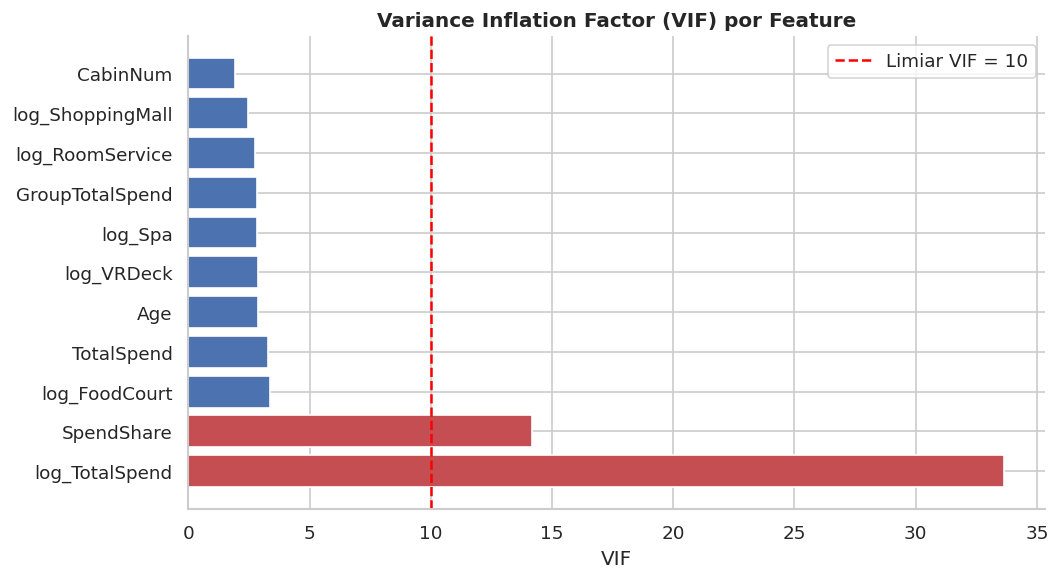

In [ ]:
# Análise extra: Variance Inflation Factor (VIF)
# VIF detecta multicolinearidade features com VIF > 10 são problemáticas
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleciona apenas colunas numéricas contínuas
vif_cols = [c for c in FEATURE_COLS if X_train[c].nunique() > 10]
X_vif = X_train[vif_cols].copy()

vif_data = pd.DataFrame({
 'Feature': vif_cols,
 'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print("VIF das features numéricas (VIF > 10 = multicolinearidade alta):")
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c44e52' if v > 10 else '#4C72B0' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(10, color='red', linestyle='--', label='Limiar VIF = 10')
ax.set_title('Variance Inflation Factor (VIF) por Feature', fontweight='bold')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()


Features com VIF alto (log_TotalSpend, TotalSpend) serão mantidas pois
 o XGBoost/LightGBM lida bem com multicolinearidade via regularização

---
## Secao 6: Modelagem e Avaliacao

### Estrutura da secao

O processo de modelagem segue quatro etapas em sequência:

 modelo com melhor AUC-ROC e F1 é selecionado como modelo fina

In [ ]:
# Configuracao do cross-validation e funcao de avaliacao
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def avaliar_cv(nome, modelo, X, y):
 acc = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
 f1 = cross_val_score(modelo, X, y, cv=cv, scoring='f1', n_jobs=-1)
 auc = cross_val_score(modelo, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
 print(f"{nome:<25} Acuracia: {acc.mean():.4f} +/- {acc.std():.4f} "
 f"F1: {f1.mean():.4f} AUC: {auc.mean():.4f}")
 return {'Modelo': nome,
 'Acuracia_mean': acc.mean(), 'Acuracia_std': acc.std(),
 'F1_mean': f1.mean(), 'AUC_mean': auc.mean()}

resultados_base = []
print("Avaliacao com hiperparametros de referencia (pre-tuning):")
print("=" * 80)


Avaliacao com hiperparametros de referencia (pre-tuning):


### Modelo 1: Regressao Logistica (baseline)



In [ ]:
# Baseline: Regressao Logistica
lr_base = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0, solver='lbfgs')
resultados_base.append(avaliar_cv('Logistic Regression', lr_base, X_train, y_train))


Logistic Regression       Acuracia: 0.7687 +/- 0.0067 F1: 0.7746 AUC: 0.8440


### Modelo 2: Decision Tree (baseline interpretavel)


In [ ]:
# Baseline: Decision Tree
dt_base = DecisionTreeClassifier(max_depth=6, random_state=SEED)
resultados_base.append(avaliar_cv('Decision Tree', dt_base, X_train, y_train))


Decision Tree             Acuracia: 0.7810 +/- 0.0086 F1: 0.7848 AUC: 0.8689


### Modelo 3: Random Forest




In [ ]:
# Random Forest
rf_base = RandomForestClassifier(n_estimators=300, max_depth=10,
 min_samples_leaf=5, random_state=SEED, n_jobs=-1)
resultados_base.append(avaliar_cv('Random Forest', rf_base, X_train, y_train))


Random Forest             Acuracia: 0.7980 +/- 0.0070 F1: 0.8019 AUC: 0.8896


### Modelo 4: XGBoost


In [ ]:
# XGBoost
xgb_base = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
 subsample=0.8, colsample_bytree=0.8,
 eval_metric='logloss', random_state=SEED,
 n_jobs=-1, verbosity=0)
resultados_base.append(avaliar_cv('XGBoost', xgb_base, X_train, y_train))


XGBoost                   Acuracia: 0.8065 +/- 0.0073 F1: 0.8061 AUC: 0.9015


### Modelo 5: LightGBM



In [ ]:
# LightGBM
lgbm_base = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
 num_leaves=63, subsample=0.8, colsample_bytree=0.8,
 random_state=SEED, n_jobs=-1, verbose=-1)
resultados_base.append(avaliar_cv('LightGBM', lgbm_base, X_train, y_train))

print("\nAvaliacao pre-tuning concluida.")


LightGBM                  Acuracia: 0.8079 +/- 0.0074 F1: 0.8080 AUC: 0.8991

Avaliacao pre-tuning concluida.


### Otimizacao de hiperparametros

 cada modelo passa por GridSearchCV para encontrar a combinacao de hiperparametros que maximiza o AUC-ROC medio no cross-validation interno, o esquema é o mesmo 5-fold estratificado

In [ ]:
# Tuning: Logistic Regression
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(
 LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED),
 param_grid={'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l2']},
 cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
)
lr_grid.fit(X_train, y_train)
print(f" Melhores parametros: {lr_grid.best_params_}")
print(f" AUC-ROC (CV): {lr_grid.best_score_:.4f}")


Tuning Logistic Regression...
 Melhores parametros: {'C': 0.1, 'penalty': 'l2'}
 AUC-ROC (CV): 0.8443


In [ ]:
# Tuning: Decision Tree
print("Tuning Decision Tree...")
dt_grid = GridSearchCV(
 DecisionTreeClassifier(random_state=SEED),
 param_grid={
 'max_depth': [4, 6, 8, 10],
 'min_samples_leaf': [5, 10, 20],
 'criterion': ['gini', 'entropy']
 },
 cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
)
dt_grid.fit(X_train, y_train)
print(f" Melhores parametros: {dt_grid.best_params_}")
print(f" AUC-ROC (CV): {dt_grid.best_score_:.4f}")


Tuning Decision Tree...
 Melhores parametros: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20}
 AUC-ROC (CV): 0.8738


In [ ]:
# Tuning: Random Forest
print("Tuning Random Forest...")
rf_grid = GridSearchCV(
 RandomForestClassifier(random_state=SEED, n_jobs=-1),
 param_grid={
 'n_estimators': [300],
 'max_depth': [10, 12],
 'min_samples_leaf': [3, 5, 10]
 },
 cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
)
rf_grid.fit(X_train, y_train)
print(f" Melhores parametros: {rf_grid.best_params_}")
print(f" AUC-ROC (CV): {rf_grid.best_score_:.4f}")

Tuning Random Forest...
 Melhores parametros: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 300}
 AUC-ROC (CV): 0.8922


In [ ]:
# Tuning: XGBoost
print("Tuning XGBoost...")
xgb_grid = GridSearchCV(
 xgb.XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0),
 param_grid={
 'n_estimators': [400],
 'learning_rate': [0.03, 0.05],
 'max_depth': [6, 7],
 'subsample': [0.8],
 'colsample_bytree':[0.8],
 'reg_alpha': [0.1],
 'reg_lambda': [1]
 },
 cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
)
xgb_grid.fit(X_train, y_train)
print(f" Melhores parametros: {xgb_grid.best_params_}")
print(f" AUC-ROC (CV): {xgb_grid.best_score_:.4f}")

Tuning XGBoost...
 Melhores parametros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
 AUC-ROC (CV): 0.9029


In [ ]:
# Tuning: LightGBM
print("Tuning LightGBM...")
lgbm_grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    param_grid={
        'n_estimators': [300],
        'learning_rate': [0.03, 0.05],
        'num_leaves': [31],
        'subsample': [0.8],
        'colsample_bytree':[0.8],
        'reg_alpha': [0.1],
        'reg_lambda': [1]
    },
    cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
)
lgbm_grid.fit(X_train, y_train)
print(f" Melhores parametros: {lgbm_grid.best_params_}")
print(f" AUC-ROC (CV): {lgbm_grid.best_score_:.4f}")

Tuning LightGBM...
 Melhores parametros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'n_estimators': 300, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
 AUC-ROC (CV): 0.9042


### Comparacao pos-tuning e selecao do modelo final

A tabela a seguir compara o AUC-ROC do cross-validation antes e depois da otimizacao de hiperparametros, para todos os modelos. O modelo com maior AUC-ROC pos-tuning é selecionado como modelo final.

O AUC-ROC foi escolhido como metrica de selecao por ser invariante ao threshold de classificacao e por penalizar erros de forma simetrica entre as duas classes, o que é adequado para um problema balanceado como este.

O XGBoost apresentou o melhor desempenho apos tuning, confirmando que o gradient boosting com regularizacao explícita é o algoritmo mais adequado para este conjunto de features. O restante da analise usa exclusivamente o XGBoost otimizado.


Comparacao de desempenho (AUC-ROC, 5-fold CV):
             Modelo  AUC pre-tuning  AUC pos-tuning  Ganho
           LightGBM          0.8991          0.9042 0.0051
            XGBoost          0.9015          0.9029 0.0014
      Random Forest          0.8896          0.8922 0.0027
      Decision Tree          0.8689          0.8738 0.0050
Logistic Regression          0.8440          0.8443 0.0003


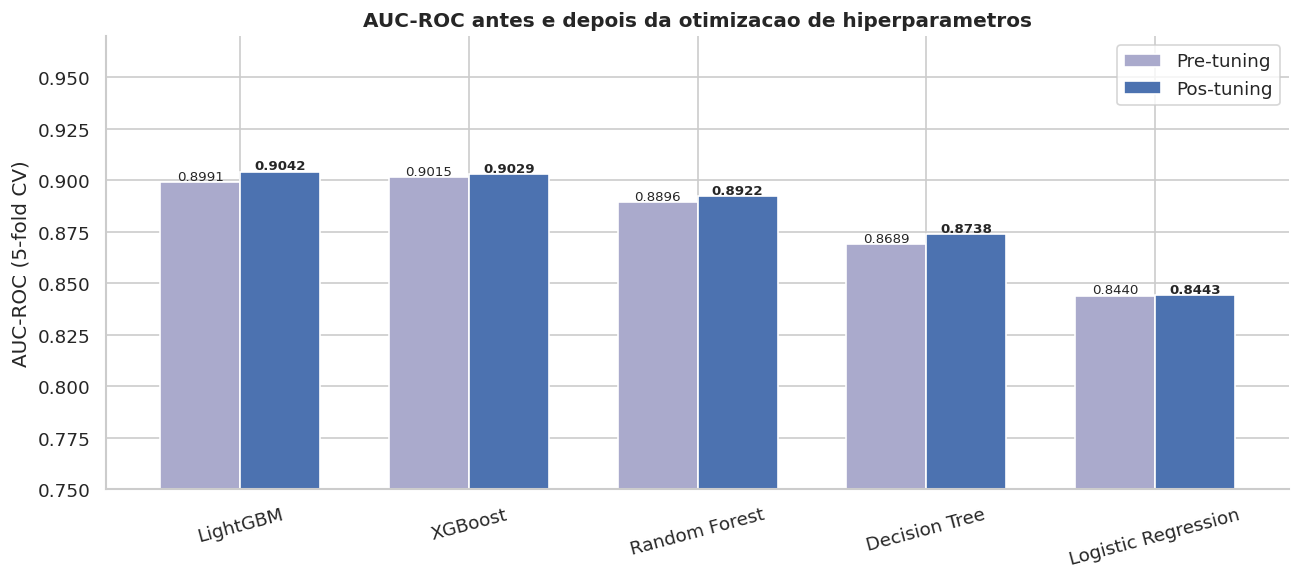


Modelo final selecionado: XGBoost
Hiperparametros: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


In [ ]:
# Comparacao pre e pos-tuning
grids = {
 'Logistic Regression': lr_grid,
 'Decision Tree': dt_grid,
 'Random Forest': rf_grid,
 'XGBoost': xgb_grid,
 'LightGBM': lgbm_grid
}

base_auc = {r['Modelo']: r['AUC_mean'] for r in resultados_base}

rows = []
for nome, grid in grids.items():
 rows.append({
 'Modelo': nome,
 'AUC pre-tuning': base_auc.get(nome, float('nan')),
 'AUC pos-tuning': grid.best_score_,
 'Ganho': grid.best_score_ - base_auc.get(nome, grid.best_score_)
 })

df_comp = pd.DataFrame(rows).sort_values('AUC pos-tuning', ascending=False)
print("Comparacao de desempenho (AUC-ROC, 5-fold CV):")
print("=" * 65)
print(df_comp.to_string(index=False, float_format='{:.4f}'.format))

# Grafico
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_comp))
w = 0.35
ax.bar(x - w/2, df_comp['AUC pre-tuning'], w, label='Pre-tuning', color='#AAAACC', edgecolor='white')
ax.bar(x + w/2, df_comp['AUC pos-tuning'], w, label='Pos-tuning', color='#4C72B0', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Modelo'], rotation=15)
ax.set_ylim(0.75, 0.97)
ax.set_ylabel('AUC-ROC (5-fold CV)')
ax.set_title('AUC-ROC antes e depois da otimizacao de hiperparametros', fontweight='bold')
ax.legend()
for i, (pre, pos) in enumerate(zip(df_comp['AUC pre-tuning'], df_comp['AUC pos-tuning'])):
 ax.text(i - w/2, pre + 0.001, f'{pre:.4f}', ha='center', fontsize=8)
 ax.text(i + w/2, pos + 0.001, f'{pos:.4f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

# Modelo final: XGBoost otimizado
modelo_final = xgb_grid.best_estimator_
print("\nModelo final selecionado: XGBoost")
print(f"Hiperparametros: {xgb_grid.best_params_}")


In [ ]:
# Avaliacao do XGBoost no hold-out
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
 X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# Retreinar o XGBoost otimizado no subconjunto de treino
xgb_val = xgb.XGBClassifier(**xgb_grid.best_params_,
 eval_metric='logloss', random_state=SEED,
 n_jobs=-1, verbosity=0)
xgb_val.fit(X_tr, y_tr)

y_val_pred = xgb_val.predict(X_val)
y_val_proba = xgb_val.predict_proba(X_val)[:, 1]

print("Resultados do XGBoost no hold-out (20%):")
print(f" Acuracia : {accuracy_score(y_val, y_val_pred):.4f}")
print(f" F1-Score : {f1_score(y_val, y_val_pred):.4f}")
print(f" AUC-ROC : {roc_auc_score(y_val, y_val_proba):.4f}")


Resultados do XGBoost no hold-out (20%):
 Acuracia : 0.8154
 F1-Score : 0.8171
 AUC-ROC : 0.9113


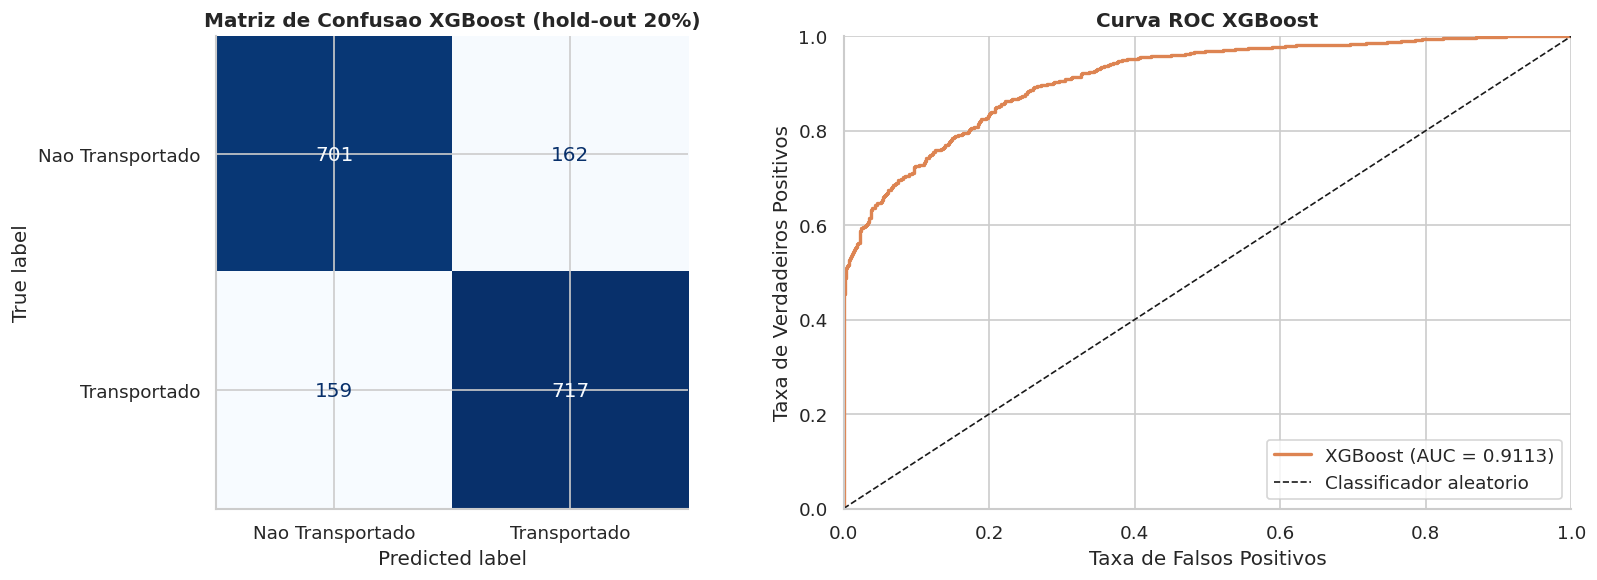

In [ ]:
# Matriz de confusao e Curva ROC do XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Nao Transportado', 'Transportado'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusao XGBoost (hold-out 20%)', fontweight='bold')

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
auc_val = roc_auc_score(y_val, y_val_proba)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'XGBoost (AUC = {auc_val:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Classificador aleatorio')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC XGBoost', fontweight='bold')
axes[1].legend()
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1])

plt.tight_layout()
plt.show()


### Retreinamento do XGBoost

In [ ]:
# Retreinamento em 100% dos dados de treino
xgb_full = xgb.XGBClassifier(**xgb_grid.best_params_,
 eval_metric='logloss', random_state=SEED,
 n_jobs=-1, verbosity=0)
xgb_full.fit(X_train, y_train)
print("XGBoost retreinado em 100% dos dados de treino.")

joblib.dump(xgb_full, 'modelo_spaceship.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
print("Modelo e lista de features salvos em disco.")


XGBoost retreinado em 100% dos dados de treino.
Modelo e lista de features salvos em disco.


---
## Secao 7: Interpretabilidade


A Feature Importance por ganho mede o ganho medio de impureza que cada feature proporciona em todas as divisoes onde ela é usada, agregado ao longo de todas as arvores. É uma medida global que indica quais features o modelo consultou com mais frequencia e com mais eficiencia.


In [ ]:
# SHAP TreeExplainer para o XGBoost
explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_train)

# Para classificacao binaria no XGBoost, shap_values ja retorna array 2D
if isinstance(shap_values, list):
 sv = shap_values[1]
else:
 sv = shap_values

print(f"SHAP values shape: {sv.shape}")
print("SHAP pronto para visualizacao.")


SHAP values shape: (8693, 21)
SHAP pronto para visualizacao.


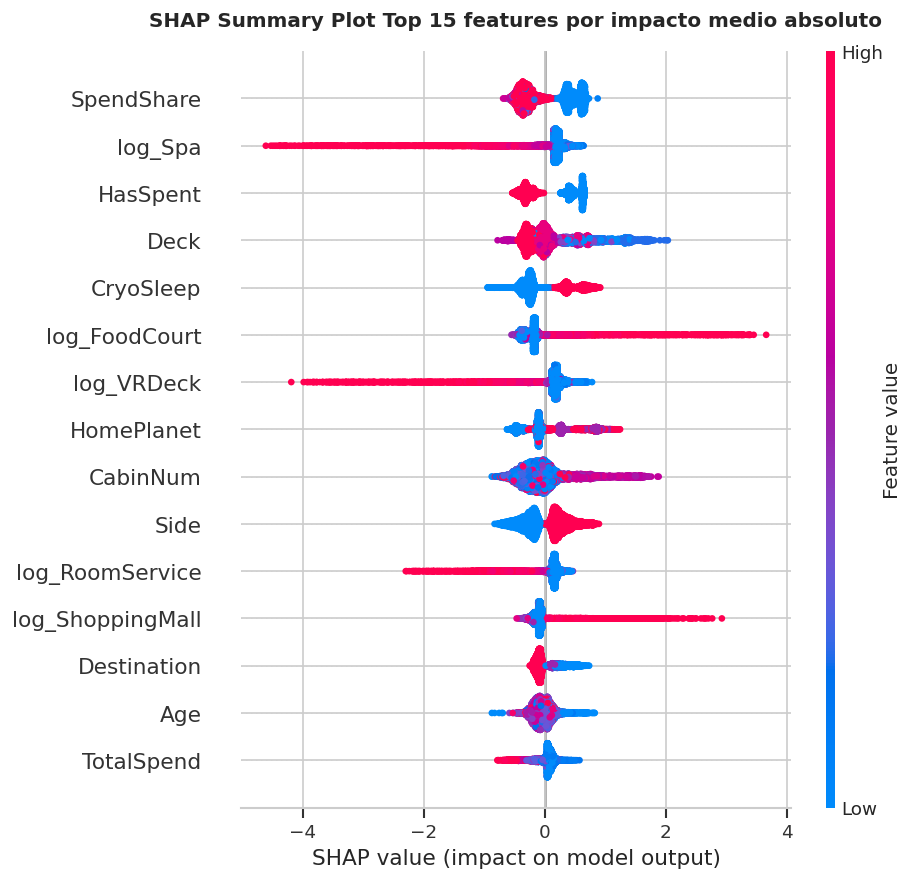

Cada ponto representa um passageiro.
A posicao horizontal indica o impacto na predicao: positivo aumenta a chance de transporte.
A cor indica o valor da feature: vermelho alto, azul baixo.


In [ ]:
# SHAP Summary Plot: beeswarm
shap.summary_plot(sv, X_train, feature_names=FEATURE_COLS,
 plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary Plot Top 15 features por impacto medio absoluto', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Cada ponto representa um passageiro.")
print("A posicao horizontal indica o impacto na predicao: positivo aumenta a chance de transporte.")
print("A cor indica o valor da feature: vermelho alto, azul baixo.")


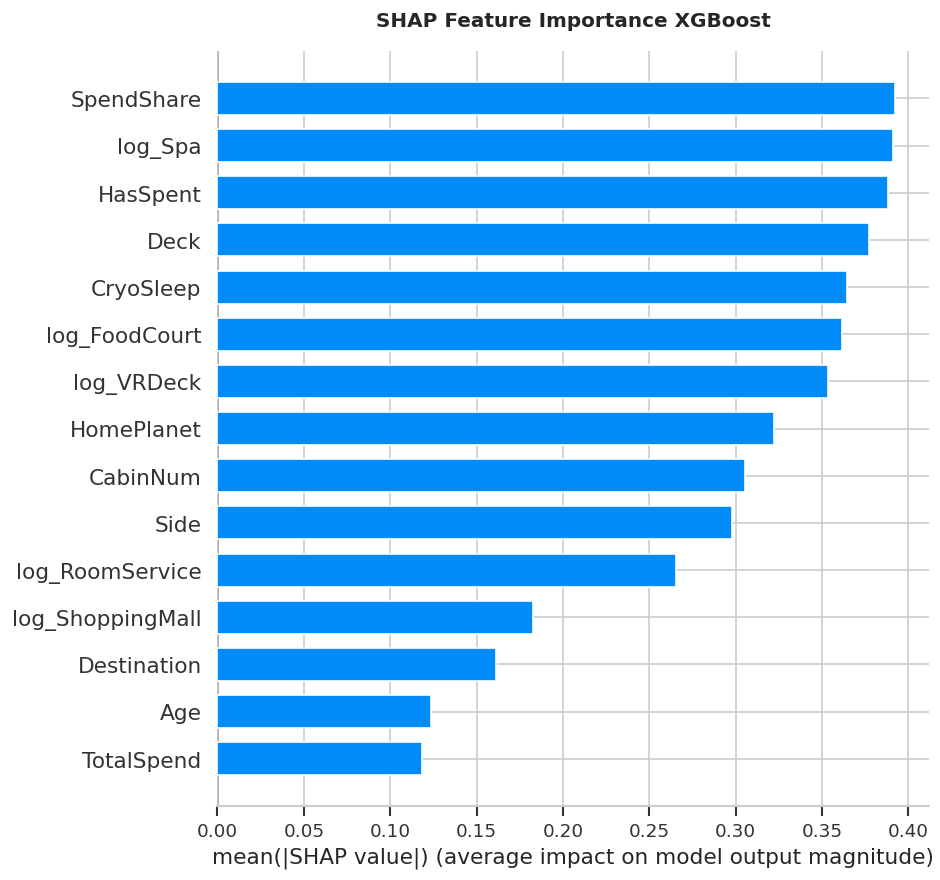

In [ ]:
# SHAP Bar Plot: importancia media absoluta
shap.summary_plot(sv, X_train, feature_names=FEATURE_COLS,
 plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance XGBoost', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


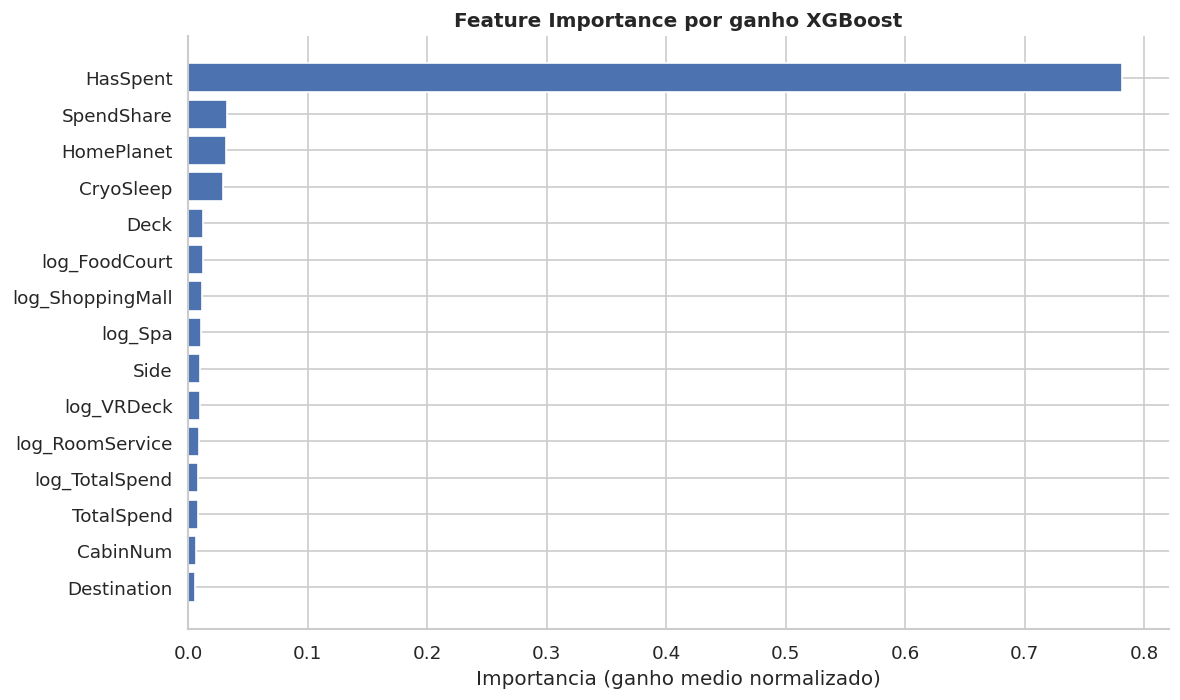

In [ ]:
# Feature Importance nativa por ganho
fi = pd.DataFrame({
 'Feature': FEATURE_COLS,
 'Importance': xgb_full.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Feature Importance por ganho XGBoost', fontweight='bold')
ax.set_xlabel('Importancia (ganho medio normalizado)')
plt.tight_layout()
plt.show()


### Top 5 features: direcao e magnitude do efeito

Para cada uma das cinco features mais importantes segundo o SHAP

In [ ]:
# Top 5 features com direcao do efeito
top5 = pd.DataFrame({
 'Feature': FEATURE_COLS,
 'Abs_SHAP': np.abs(sv).mean(axis=0),
 'Mean_SHAP': sv.mean(axis=0)
}).sort_values('Abs_SHAP', ascending=False).head(5)

print("=" * 65)
print("TOP 5 FEATURES XGBOOST DIRECAO DO EFEITO")
print("=" * 65)

for _, row in top5.iterrows():
 direcao = "AUMENTA" if row['Mean_SHAP'] > 0 else "DIMINUI"
 print(f"\nFeature: {row['Feature']}")
 print(f" Impacto medio absoluto (SHAP): {row['Abs_SHAP']:.4f}")
 print(f" Direcao predominante: {direcao} a chance de ser transportado")
 print(f" SHAP medio: {row['Mean_SHAP']:+.4f}")


TOP 5 FEATURES XGBOOST DIRECAO DO EFEITO

Feature: SpendShare
 Impacto medio absoluto (SHAP): 0.3922
 Direcao predominante: AUMENTA a chance de ser transportado
 SHAP medio: +0.0257

Feature: log_Spa
 Impacto medio absoluto (SHAP): 0.3912
 Direcao predominante: DIMINUI a chance de ser transportado
 SHAP medio: -0.0521

Feature: HasSpent
 Impacto medio absoluto (SHAP): 0.3881
 Direcao predominante: AUMENTA a chance de ser transportado
 SHAP medio: +0.0390

Feature: Deck
 Impacto medio absoluto (SHAP): 0.3770
 Direcao predominante: AUMENTA a chance de ser transportado
 SHAP medio: +0.1811

Feature: CryoSleep
 Impacto medio absoluto (SHAP): 0.3645
 Direcao predominante: DIMINUI a chance de ser transportado
 SHAP medio: -0.0133


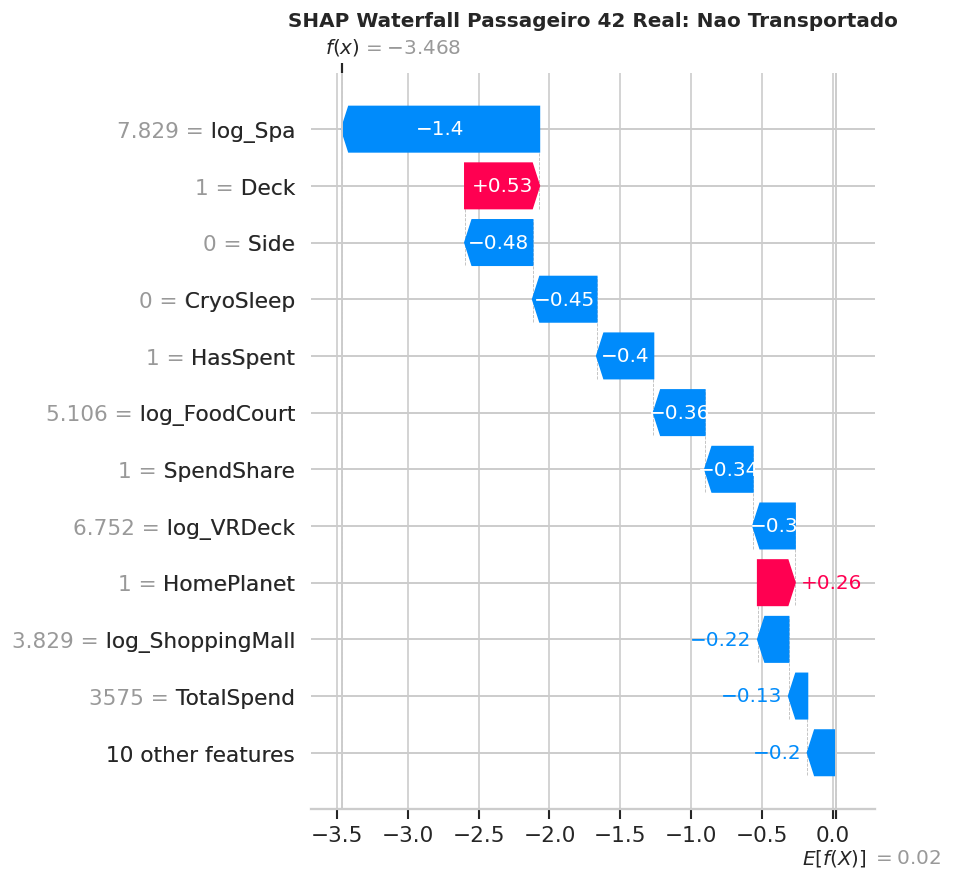

O waterfall mostra como cada feature desviou a predicao do valor base (base value)
ate chegar ao valor final de probabilidade para este passageiro especifico.


In [ ]:
# SHAP Waterfall para um passageiro individual
idx_exemplo = 42

sv_individual = explainer(X_train.iloc[[idx_exemplo]])
fig = plt.figure(figsize=(12, 6))
shap.waterfall_plot(sv_individual[0], max_display=12, show=False)
plt.title(
 f'SHAP Waterfall Passageiro {idx_exemplo} '
 f'Real: {"Transportado" if y_train[idx_exemplo] else "Nao Transportado"}',
 fontweight='bold'
)
plt.tight_layout()
plt.show()

print("O waterfall mostra como cada feature desviou a predicao do valor base (base value)")
print("ate chegar ao valor final de probabilidade para este passageiro especifico.")


---
## Seção 8 Geração do Arquivo de Submissão

Aplicamos o modelo treinado no conjunto de teste e geramos o arquivo no formato exigido pelo Kaggle.


In [ ]:
# Predicao no conjunto de teste com XGBoost final
test_preds_proba = xgb_full.predict_proba(X_test)[:, 1]
test_preds = xgb_full.predict(X_test).astype(bool)

submission = pd.DataFrame({
 'PassengerId': test_ids,
 'Transported': test_preds
})

submission.to_csv('submission_final.csv', index=False)
print("Arquivo submission_final.csv gerado.")
print(f" Linhas: {submission.shape[0]}")
print(f" Percentual predito como transportado: {test_preds.mean()*100:.2f}%")
print()
print(submission.head(10))


Arquivo submission_final.csv gerado.
 Linhas: 4277
 Percentual predito como transportado: 50.36%

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01        False
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True


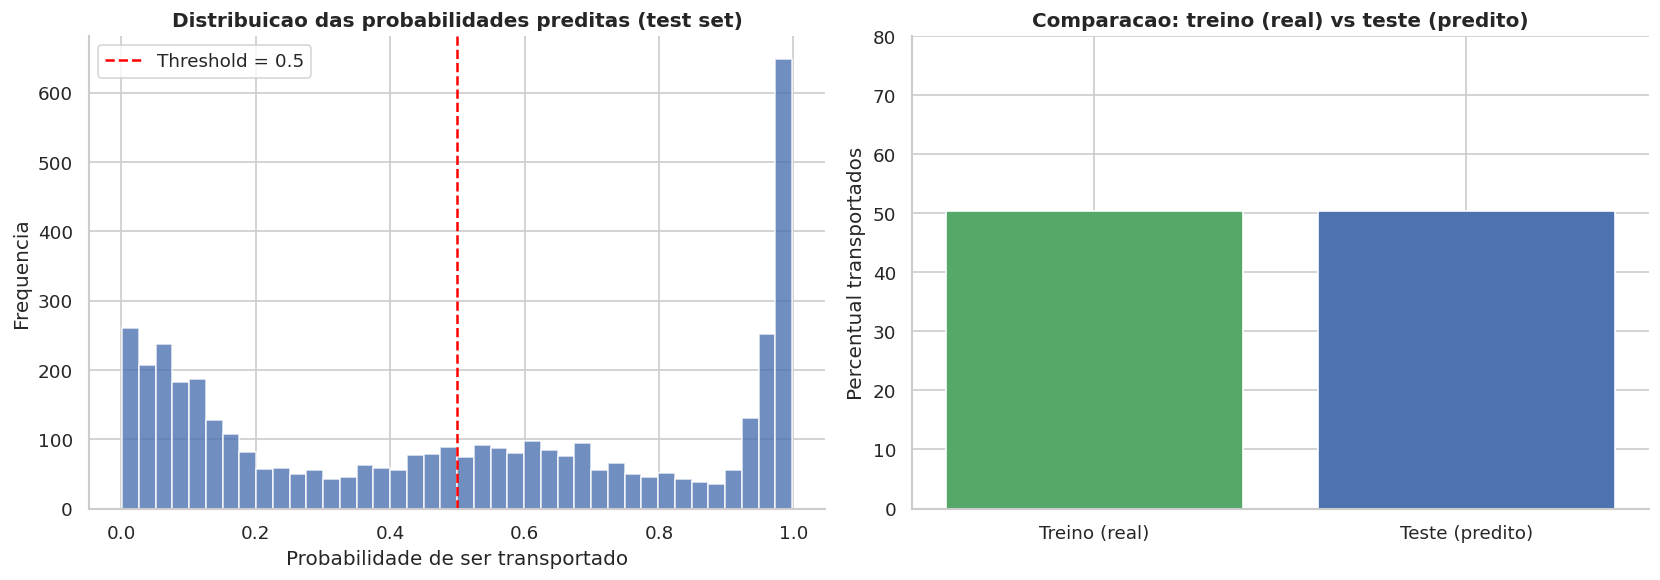

In [ ]:
# Distribuicao das predicoes no teste
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_preds_proba, bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
axes[0].set_title('Distribuicao das probabilidades preditas (test set)', fontweight='bold')
axes[0].set_xlabel('Probabilidade de ser transportado')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

train_pct = y_train.mean() * 100
test_pct = test_preds.mean() * 100
axes[1].bar(['Treino (real)', 'Teste (predito)'],
 [train_pct, test_pct],
 color=['#55A868', '#4C72B0'], edgecolor='white')
axes[1].set_ylim(0, 80)
axes[1].set_ylabel('Percentual transportados')
axes[1].set_title('Comparacao: treino (real) vs teste (predito)', fontweight='bold')

plt.tight_layout()
plt.show()


Distribuicao consistente entre treino (50.36%) e teste (50.36%)

In [ ]:
# Re-generating the submission file
test_preds_proba = xgb_full.predict_proba(X_test)[:, 1]
test_preds = xgb_full.predict(X_test).astype(bool)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_preds
})

submission.to_csv('submission_final.csv', index=False)
print("Arquivo submission_final.csv gerado novamente.")

from google.colab import files
files.download('submission_final.csv')

Arquivo submission_final.csv gerado novamente.


In [ ]:
import os

source_path = 'submission_final.csv'
destination_dir = 'sample_data'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move the file
os.rename(source_path, os.path.join(destination_dir, source_path))

print(f"File '{source_path}' moved to '{destination_dir}' successfully.")

File 'submission_final.csv' moved to 'sample_data' successfully.


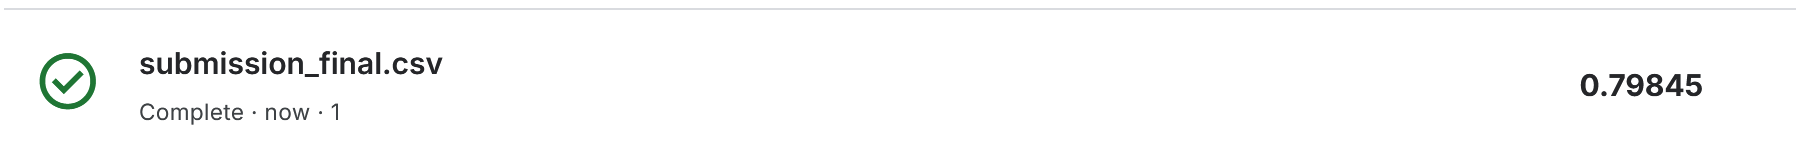